<a href="https://colab.research.google.com/github/JSEFERINO/DISE-O2025/blob/main/202506_DOE_DOS_FACTORES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Diseño Factorial - Dos factores 2025**


<a name="inicio"></a>


## **1.** [Librerias para Trabar en R y Colab](#T1)
## **2.** [Diseño Factorial -Dos Factores usando Python](#T2)

## **3.** [Los Datos del Problema](#T3)

## **4.** [BoxPlot para el Diseño Factorial](#T4)

## **5.** [Análisis de Varianza](#T5)

## **6.** [Diferentes componentes de tu modelo](#T6)

## **7.** [Gráfico de interacciones entre los factores](#T7)


## **8.** [Comparaciones Múltiples - DCGL - HSD - Para las Formulaciones](#T8)

## **9.** [Comparaciones Multiples de Medias para el Factor Principal - Intervalos de Confianza - LSD](#T9)


## **10.** [Comparaciones Múltiples: FORMS - 05: LSD y HSD](#T10)

## **11.** [Las diferencias entre las medias entre las formulaciones - Caso 2 poblaciones](#T11)

## **12.** [Supuestos del Modelo : Normalidad](#T12)

## **13.** [Supuestos del Modelo = Homocedasticidad](#T13)



## **15.** [](#T15)


[⬆️ Volver al inicio](#inicio)

<a name="T1"></a>
## **1. Librerias para Trabar en R y Colab**


In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

In [ ]:
# @title **B. Librerias para Trabar en R y Colab**

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import statsmodels
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.formula.api as smf
import scipy.stats as stats

from statsmodels.graphics.factorplots import interaction_plot
#!pip install bioinfokit
#from bioinfokit.analys import stat
!pip install pingouin
import pingouin as pg


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 6.3 MB/s eta 0:00:00


[⬆️ Volver al inicio](#inicio)

<a name="T2"></a>
## **2. Diseño Factorial -Dos Factores usando Python - Aplicación**


#  **Tema 6: Diseño Factorial -Dos Factores usando Python**

##  **Ejemplo de un Diseño Factorial $4\bigotimes3$**.

### **Consideremos un experimento en el que se quiere estudiar el efecto de los factores velocidad de alimentación y profundidad de corte sobre el acabado de un metal. Aunque los factores son de naturaleza continua, en este proceso sólo se pueden trabajar en 3 y 4 niveles, respectivamente. Por ello, se decide correr un factorial completo $4\bigotimes3$ con tres réplicas, que permitirá obtener toda la información relevante en relación al efecto de estos factores sobre el acabado. Aleatorizando las 36 pruebas se obtienen los datos en la tabla siguiente. El acabado ($Y$) está en unidades de gramos e interesa minimizar su valor.**

|B: Velocidad \ A: Profundidad|	0.15	|0.18	|0.21	|0.24|
|:--:|:--:|:--:|:--:|:--:|
|0.20	|74, 64, 60|	79, 68, 73|	82, 88, 92|	99, 104, 96|
|0.25	|92, 86, 88|	98, 104, 88|	99, 108, 95|	104, 110, 99|
|0.30	|99, 98, 102|	104, 99, 95	|108, 110, 99|	114, 111, 107|



[⬆️ Volver al inicio](#inicio)

<a name="T3"></a>
## **3. Los Datos del Problema**


In [ ]:
#@title **A Los Datos del Problema**
Profundidad  =  ([0.15]*3+[0.18]*3+[0.21]*3+[0.24]*3)*3
Velocidad  =  [0.20]*12+[0.25]*12+[0.30]*12

Acabado =[74, 64, 60, 79, 68, 73, 82, 88, 92, 99, 104, 96, 92,
          86, 88,	98, 104, 88,	99, 108, 95,	104, 110, 99, 99,
          98, 102,	104, 99, 95,	108, 110, 99,	114, 111, 107]

# Construyamos el dataFrame de los datos**
D2F = pd.DataFrame({'Velocidad':Velocidad, 'Profundidad':Profundidad, 'Acabado':Acabado})




In [ ]:
# @title **B. Visualizando el DataFrame**
D2F


,Velocidad,Profundidad,Acabado
0,0.20,0.15,74
1,0.20,0.15,64
2,0.20,0.15,60
3,0.20,0.18,79
4,0.20,0.18,68
5,0.20,0.18,73
6,0.20,0.21,82
7,0.20,0.21,88
8,0.20,0.21,92
9,0.20,0.24,99


[⬆️ Volver al inicio](#inicio)

<a name="T4"></a>
## **4. BoxPlot para el DCGL**


<Axes: title={'center': 'Acabado vs Profundidad'}, xlabel='Profundidad', ylabel='Acabado'>

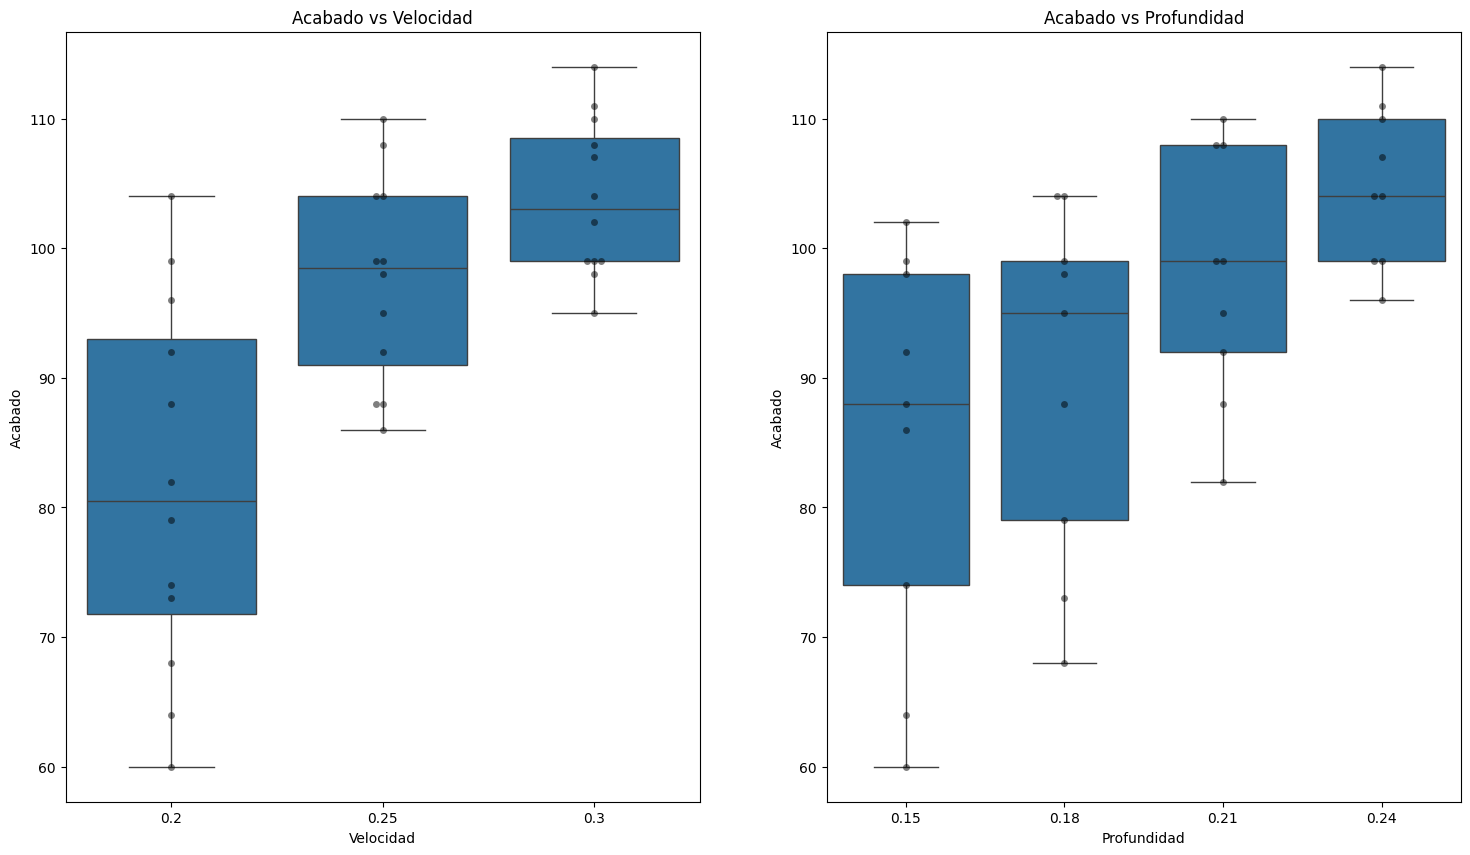

In [ ]:
# @title **A. BoxPlot para el DCGL**
fig, axs = plt.subplots(1, 2, figsize=(18, 10))
axs[0].set_title('Acabado vs Velocidad')
sns.boxplot(x="Velocidad", y="Acabado", data=D2F, ax=axs[0])
sns.swarmplot(x="Velocidad", y="Acabado", data=D2F, color='black',
              alpha = 0.5, ax=axs[0])

axs[1].set_title('Acabado vs Profundidad')
sns.boxplot(x="Profundidad", y="Acabado", data=D2F, ax=axs[1])
sns.swarmplot(x="Profundidad", y="Acabado", data=D2F, color='black',
              alpha = 0.5, ax=axs[1])


/tmp/ipython-input-3748545169.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Velocidad", y="Acabado", data=D2F, ax=axs[0], palette='Set1')  # Cambiar color de las cajas
/tmp/ipython-input-3748545169.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Profundidad", y="Acabado", data=D2F, ax=axs[1], palette='Set2')  # Cambiar color de las cajas


<Axes: title={'center': 'Acabado vs Profundidad'}, xlabel='Profundidad', ylabel='Acabado'>

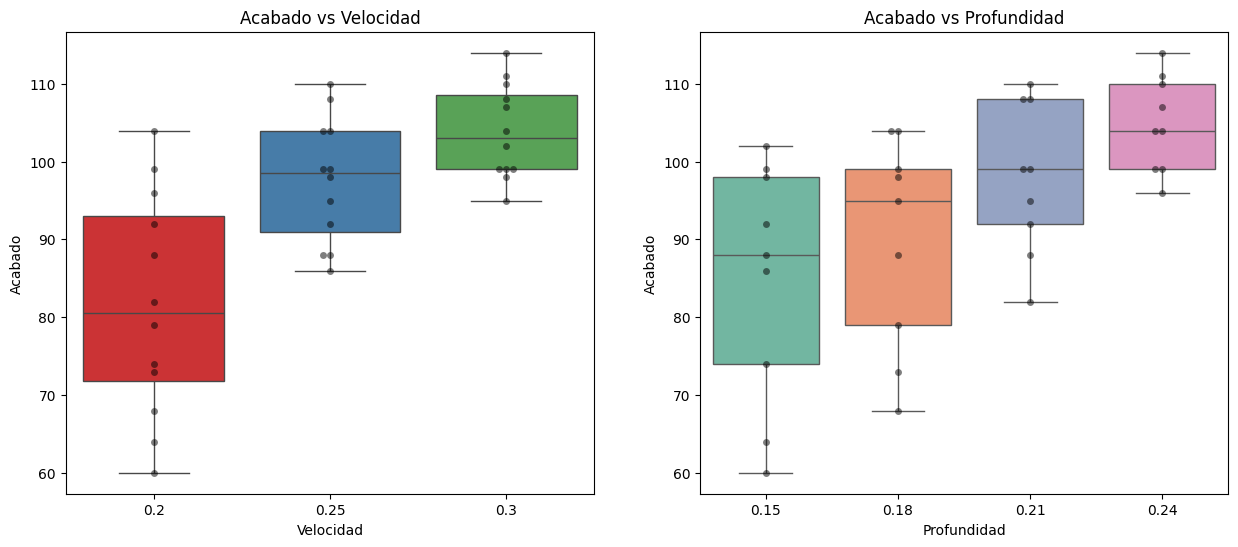

In [ ]:

# @title **B. BoxPlot para el D2F - Mejorando colores**
fig, axs = plt.subplots(1, 2, figsize=(15, 6))
axs[0].set_title('Acabado vs Velocidad')
sns.boxplot(x="Velocidad", y="Acabado", data=D2F, ax=axs[0], palette='Set1')  # Cambiar color de las cajas
sns.swarmplot(x="Velocidad", y="Acabado", data=D2F, color='black',
              alpha = 0.5, ax=axs[0])

axs[1].set_title('Acabado vs Profundidad')
sns.boxplot(x="Profundidad", y="Acabado", data=D2F, ax=axs[1], palette='Set2')  # Cambiar color de las cajas
sns.swarmplot(x="Profundidad", y="Acabado", data=D2F, color='black',
              alpha = 0.5, ax=axs[1])


/tmp/ipython-input-2418776421.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box1 = sns.boxplot(x="Velocidad", y="Acabado", data=D2F, ax=axs[0],
/tmp/ipython-input-2418776421.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box2 = sns.boxplot(x="Profundidad", y="Acabado", data=D2F, ax=axs[1],


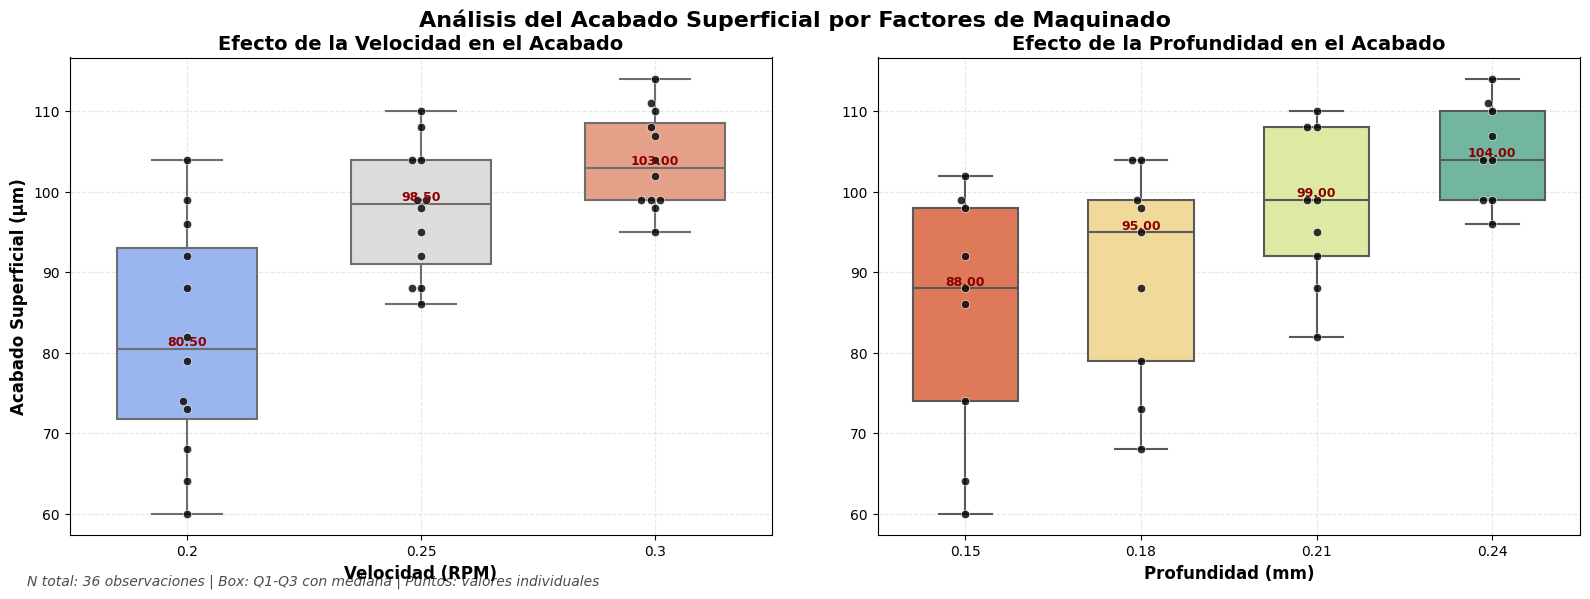


RESUMEN ESTADÍSTICO - ACABADO SUPERFICIAL
Por Velocidad:
           count        mean        std   min    max
Velocidad                                           
0.20        12.0   81.583333  14.336592  60.0  104.0
0.25        12.0   97.583333   8.005207  86.0  110.0
0.30        12.0  103.833333   6.072791  95.0  114.0

Por Profundidad:
             count        mean        std   min    max
Profundidad                                           
0.15           9.0   84.777778  15.409232  60.0  102.0
0.18           9.0   89.777778  13.507200  68.0  104.0
0.21           9.0   97.888889   9.662355  82.0  110.0
0.24           9.0  104.888889   6.132790  96.0  114.0


In [ ]:
# @title **C. BoxPlot para el D2F - Análisis de Acabado por Factores**
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuración de estilo
plt.style.use('default')
sns.set_palette("viridis")

fig, axs = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Análisis del Acabado Superficial por Factores de Maquinado',
             fontsize=16, fontweight='bold', y=0.98)

# Primer subplot: Acabado vs Velocidad
axs[0].set_title('Efecto de la Velocidad en el Acabado', fontsize=14, fontweight='semibold')
box1 = sns.boxplot(x="Velocidad", y="Acabado", data=D2F, ax=axs[0],
                  palette='coolwarm', width=0.6, linewidth=1.5)
sns.swarmplot(x="Velocidad", y="Acabado", data=D2F, color='black',
              size=6, alpha=0.8, edgecolor='white', linewidth=0.5, ax=axs[0])

# Mejorar el primer subplot
axs[0].set_xlabel('Velocidad (RPM)', fontsize=12, fontweight='bold')
axs[0].set_ylabel('Acabado Superficial (μm)', fontsize=12, fontweight='bold')
axs[0].grid(True, alpha=0.3, linestyle='--')
axs[0].tick_params(axis='both', which='major', labelsize=10)

# Segundo subplot: Acabado vs Profundidad
axs[1].set_title('Efecto de la Profundidad en el Acabado', fontsize=14, fontweight='semibold')
box2 = sns.boxplot(x="Profundidad", y="Acabado", data=D2F, ax=axs[1],
                  palette='Spectral', width=0.6, linewidth=1.5)
sns.swarmplot(x="Profundidad", y="Acabado", data=D2F, color='black',
              size=6, alpha=0.8, edgecolor='white', linewidth=0.5, ax=axs[1])

# Mejorar el segundo subplot
axs[1].set_xlabel('Profundidad (mm)', fontsize=12, fontweight='bold')
axs[1].set_ylabel('')  # Remover label duplicado
axs[1].grid(True, alpha=0.3, linestyle='--')
axs[1].tick_params(axis='both', which='major', labelsize=10)

# Añadir estadísticas descriptivas
for i, ax in enumerate(axs):
    # Calcular y mostrar medianas
    if i == 0:
        groups = D2F.groupby('Velocidad')['Acabado']
    else:
        groups = D2F.groupby('Profundidad')['Acabado']

    for j, (name, group) in enumerate(groups):
        median_val = group.median()
        ax.text(j, median_val, f'{median_val:.2f}',
                ha='center', va='bottom', fontweight='bold',
                fontsize=9, color='darkred')

# Ajustar layout
plt.tight_layout()
plt.subplots_adjust(top=0.9, wspace=0.15)

# Añadir anotación informativa
fig.text(0.02, 0.02, f'N total: {len(D2F)} observaciones | Box: Q1-Q3 con mediana | Puntos: valores individuales',
         fontsize=10, style='italic', alpha=0.7)

plt.show()

# Mostrar resumen estadístico
print("\n" + "="*60)
print("RESUMEN ESTADÍSTICO - ACABADO SUPERFICIAL")
print("="*60)
print("Por Velocidad:")
print(D2F.groupby('Velocidad')['Acabado'].describe()[['count', 'mean', 'std', 'min', 'max']])
print("\nPor Profundidad:")
print(D2F.groupby('Profundidad')['Acabado'].describe()[['count', 'mean', 'std', 'min', 'max']])

[⬆️ Volver al inicio](#inicio)

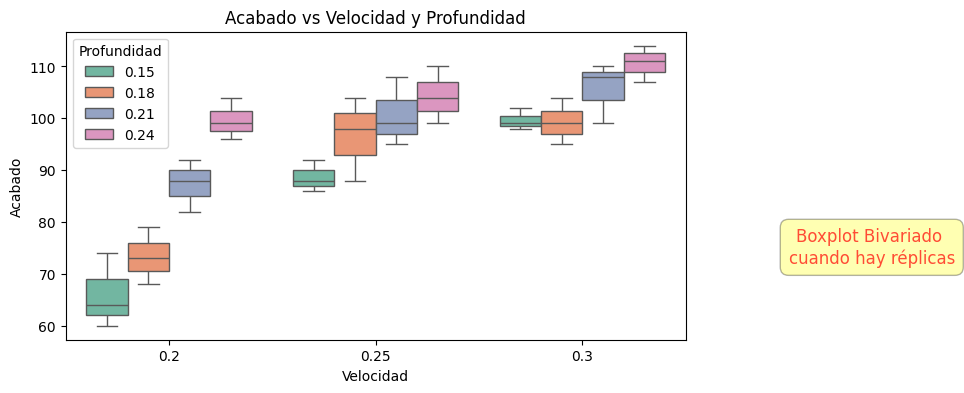

In [ ]:
# @title **D. BoxPlot para el D2F - No es posible dado que no hay réplicas**
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.set_title('Acabado vs Velocidad y Profundidad')
sns.boxplot(x="Velocidad", y="Acabado", hue='Profundidad', data=D2F, ax=ax, palette='Set2')
ax.text(1.3, 0.3, 'Boxplot Bivariado \ncuando hay réplicas',
        transform=ax.transAxes, ha='center', va='center',
        fontsize=12, color='red', alpha=0.7,
        bbox=dict(boxstyle="round,pad=0.5", facecolor="yellow", alpha=0.3))
plt.show()

[⬆️ Volver al inicio](#inicio)

<a name="T5"></a>
## **5. Análisis de Varianza**




In [ ]:
#@title **A. Media y desviación estandard**
print('Acabado media y desviación típica por Velocidad')
D2F.groupby('Velocidad')['Acabado'].agg(['mean', 'std'])

Acabado media y desviación típica por Velocidad


,mean,std
Velocidad,,
0.20,81.583333,14.336592
0.25,97.583333,8.005207
0.30,103.833333,6.072791


In [ ]:
#@title **B. Media y desviación estandard**
print('Acabado media y desviación típica por Profundidad')
D2F.groupby('Profundidad')['Acabado'].agg(['mean', 'std'])

Acabado media y desviación típica por Profundidad


,mean,std
Profundidad,,
0.15,84.777778,15.409232
0.18,89.777778,13.507200
0.21,97.888889,9.662355
0.24,104.888889,6.132790


In [ ]:
#@title **C. Media y desviación estandard por combinación de Factores**
print('Resistencia media y desviación típica por templado y grosor')
D2F.groupby(['Velocidad', 'Profundidad'])['Acabado'].agg(['mean', 'std'])

Resistencia media y desviación típica por templado y grosor


mean       std
Velocidad Profundidad                      
0.20      0.15          66.000000  7.211103
          0.18          73.333333  5.507571
          0.21          87.333333  5.033223
          0.24          99.666667  4.041452
0.25      0.15          88.666667  3.055050
          0.18          96.666667  8.082904
          0.21         100.666667  6.658328
          0.24         104.333333  5.507571
0.30      0.15          99.666667  2.081666
          0.18          99.333333  4.509250
          0.21         105.666667  5.859465
          0.24         110.666667  3.511885

[⬆️ Volver al inicio](#inicio)

In [ ]:
#@title **D. Análisis del Modelo Lineal General:$Acabado_{ijk} = (Velocidad)_i + (Profundidad)_j+(Velocidad*Profundidad)_{ij} + \epsilon_{ijk}$**
modeloD2F = smf.ols("Acabado ~ C(Velocidad) + C(Profundidad)+C(Velocidad) * C(Profundidad)", data = D2F).fit()
print(modeloD2F.summary())

                            OLS Regression Results                            
Dep. Variable:                Acabado   R-squared:                       0.894
Model:                            OLS   Adj. R-squared:                  0.846
Method:                 Least Squares   F-statistic:                     18.49
Date:                Fri, 12 Sep 2025   Prob (F-statistic):           4.11e-09
Time:                        15:25:59   Log-Likelihood:                -104.22
No. Observations:                  36   AIC:                             232.4
Df Residuals:                      24   BIC:                             251.4
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

In [ ]:
#@title **E. Análisis de Varianza de las componentes del Modelo Tipo II**
modeloD2F = ols("Acabado ~ C(Velocidad) + C(Profundidad)+C(Velocidad) * C(Profundidad)", data = D2F).fit()
anova_result = sm.stats.anova_lm(modeloD2F, typ=2)
print (anova_result)

                                  sum_sq    df          F        PR(>F)
C(Velocidad)                 3160.500000   2.0  55.018375  1.086046e-09
C(Profundidad)               2125.111111   3.0  24.662798  1.652000e-07
C(Velocidad):C(Profundidad)   557.055556   6.0   3.232431  1.797302e-02
Residual                      689.333333  24.0        NaN           NaN


[⬆️ Volver al inicio](#inicio)

In [ ]:
#@title **F. Análisis de Varianza de las componentes del Modelo Tipo II**


pg.anova(
    data     = D2F,
    dv       = 'Acabado',
    between  = ['Velocidad', 'Profundidad'],
    detailed = True
).round(4)

,Source,SS,DF,MS,F,p-unc,np2
0,Velocidad,3160.5000,2,1580.2500,55.0184,0.000,0.8209
1,Profundidad,2125.1111,3,708.3704,24.6628,0.000,0.7551
2,Velocidad * Profundidad,557.0556,6,92.8426,3.2324,0.018,0.4469
3,Residual,689.3333,24,28.7222,NaN,NaN,NaN


[⬆️ Volver al inicio](#inicio)

<a name="T7"></a>
## **7. Gráfico de interacciones entre los factores**




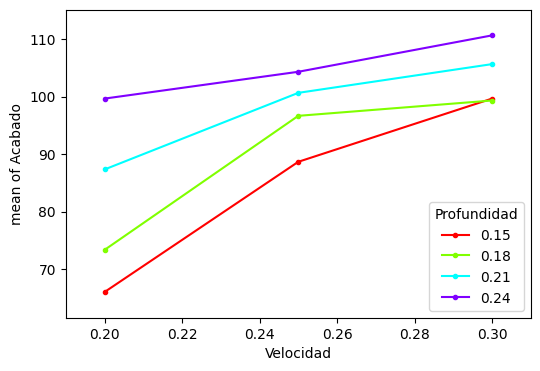

In [ ]:
# @title **A Gráfico de interacciones A*B**
fig, ax = plt.subplots(figsize=(6, 4))
fig = interaction_plot(
    x        = D2F.Velocidad,
    trace    = D2F.Profundidad,
    response = D2F.Acabado,
    ax       = ax,
)

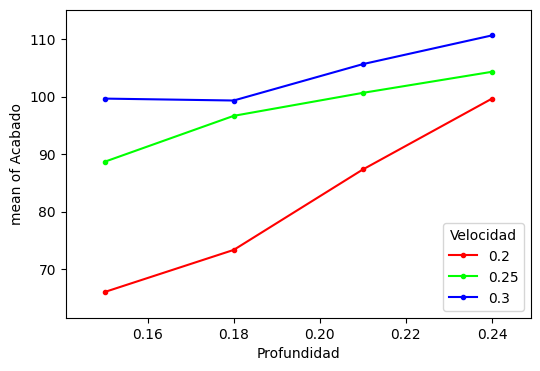

In [ ]:
# @title **A Gráfico de interacciones B*A**
fig, ax = plt.subplots(figsize=(6, 4))
fig = interaction_plot(
    x        = D2F.Profundidad,
    trace    = D2F.Velocidad,
    response = D2F.Acabado,
    ax       = ax,
)

[⬆️ Volver al inicio](#inicio)

<a name="T8"></a>
## **8. Comparaciones Múltiples - HSD - Para las Formulaciones**


# **A. Prueba de rangos múltiples de Tukey** o **HSD (Honestly Significant Difference)**
+ La **prueba de rangos múltiples de Tukey** o **HSD (Honestly Significant Difference)** es un método para comparar medias en análisis de varianza (ANOVA) y se utiliza en diseños como el **cuadrado latino** para realizar comparaciones múltiples entre grupos. En este caso, es adecuada para comparar las medias de tratamientos tras realizar un ANOVA en un diseño de cuadrado latino.

+ La fórmula general para calcular la **diferencia honestamente significativa** (HSD) es la siguiente:

$$
HSD = q_{\alpha, k, \text{df}_E} \cdot \sqrt{\frac{MS_E}{n}}
$$

### Donde:
- $ q_{\alpha, k, \text{df}_E} $ es el **valor crítico de Tukey** obtenido de la **distribución de studentizada $ q $**. Este valor depende del nivel de significancia $ \alpha $, el número de grupos $ k $, y los grados de libertad del error $ \text{df}_E $ (generalmente obtenidos del análisis de varianza).
- $MS_E$ es el **cuadrado medio del error**, también obtenido del ANOVA.
- $ n $ es el número de observaciones en cada grupo (en el diseño de cuadrado latino, este valor generalmente será el mismo para todos los grupos).

### Paso a Paso:

1. **Realizar el ANOVA**: Primero se debe ejecutar el ANOVA para obtener $ MS_E $ y los grados de libertad del error $ \text{df}_E $.
   
2. **Obtener el valor crítico de Tukey** $ q_{\alpha, k, \text{df}_E} $: Este valor se busca en tablas de la distribución de studentizada $ q $ para el nivel de significancia deseado ($ \alpha $), el número de tratamientos $ k $, y los grados de libertad del error.

3. **Calcular el valor HSD**: Usando la fórmula $ HSD = q_{\alpha, k, \text{df}_E} \cdot \sqrt{\frac{MS_E}{n}} $, se calcula el valor de la diferencia mínima significativa.

4. **Comparar las diferencias entre las medias**: Si la diferencia entre dos medias es mayor que el valor de $ HSD $, entonces esas dos medias son significativamente diferentes entre sí.

### Ejemplo Rápido:

Supongamos que tenemos los siguientes valores tras realizar un ANOVA:
- $ MS_E = 15.2 $
- $ n = 6 $ (6 observaciones por grupo)
- $ k = 4 $ (4 tratamientos)
- $ \text{df}_E = 12 $ (grados de libertad del error)

Buscamos en una tabla de Tukey para $ q_{\alpha=0.05, 4, 12} $ y obtenemos $ q = 4.20 $.

Entonces, el valor $ HSD $ sería:

$$
HSD = 4.20 \cdot \sqrt{\frac{15.2}{6}} = 4.20 \cdot \sqrt{2.53} = 4.20 \cdot 1.59 = 6.678
$$

Cualquier diferencia entre las medias mayor a 6.678 será considerada significativa.

[⬆️ Volver al inicio](#inicio)

# **B. Aquí tienes cómo puedes llamar a diferentes componentes de tu modelo**
`modeloDCL` (ajustado con `ols`), basado en el uso de `statsmodels` en Python. El modelo ajustado contiene varios atributos que te permiten acceder a diferentes resultados estadísticos:

1. **Grados de libertad del error (residuales)**:
   ```python
   dl_error = modeloDCL.df_resid
   ```

2. **Grados de libertad del modelo (número de parámetros estimados menos 1)**:
   ```python
   dl_modelo = modeloDCL.df_model
   ```

3. **Coeficientes estimados (parámetros del modelo)**:
   ```python
   coeficientes = modeloDCL.params
   ```

4. **Error estándar de los coeficientes**:
   ```python
   errores_estandar = modeloDCL.bse
   ```

5. **Estadísticos t (valores t para los coeficientes)**:
   ```python
   t_values = modeloDCL.tvalues
   ```

6. **Valores p (p-valores asociados a los coeficientes)**:
   ```python
   p_values = modeloDCL.pvalues
   ```

7. **R-cuadrado (coeficiente de determinación)**:
   ```python
   r_cuadrado = modeloDCL.rsquared
   ```

8. **R-cuadrado ajustado**:
   ```python
   r_cuadrado_ajustado = modeloDCL.rsquared_adj
   ```

9. **Suma de cuadrados residual (SSE - Suma de cuadrados de los errores)**:
   ```python
   suma_cuadrados_resid = modeloDCL.ssr
   ```

10. **Suma de cuadrados del modelo (Sum of Squares Regression)**:
    ```python
    suma_cuadrados_modelo = modeloDCL.ess
    ```

11. **Valor F del modelo (para la prueba F general)**:
    ```python
    f_value = modeloDCL.fvalue
    ```

12. **P-valor de la prueba F**:
    ```python
    f_p_value = modeloDCL.f_pvalue
    ```

13. **Valores ajustados (valores predichos por el modelo)**:
    ```python
    valores_ajustados = modeloDCL.fittedvalues
    ```

14. **Residuos (errores del modelo)**:
    ```python
    residuos = modeloDCL.resid
    ```

15. **Covarianza de los parámetros estimados**:
    ```python
    covarianza_parametros = modeloDCL.cov_params()
    ```

Cada uno de estos componentes te da información clave sobre el ajuste del modelo y sus características estadísticas.

Para obtener los grados de libertad de un factor en un modelo lineal, como los definidos por la fórmula en `modeloDCL = ols("Tiempo ~ CATALIZADOR + LOTE + Dia", data=DCL).fit()`, puedes calcularlos de la siguiente manera:

### Grados de libertad de un factor específico:

1. **Grados de libertad del factor `CATALIZADOR`**:
   Los grados de libertad de un factor categórico en un modelo son iguales al número de niveles del factor menos uno, porque uno de los niveles se usa como referencia.

   ```python
   dl_catalizador = len(DCL['CATALIZADOR'].unique()) - 1
   ```

2. **Grados de libertad del factor `LOTE`**:
   Similarmente, para el factor `LOTE`:

   ```python
   dl_lote = len(DCL['LOTE'].unique()) - 1
   ```

3. **Grados de libertad del factor `Dia`**:
   Si `Dia` es también un factor categórico (por ejemplo, días de la semana), sus grados de libertad serían:

   ```python
   dl_dia = len(DCL['Dia'].unique()) - 1
   ```

### Explicación:
- Los **grados de libertad de un factor** categórico en un modelo lineal dependen del número de niveles (categorías) que tenga ese factor.
- Se resta 1 porque uno de los niveles es tomado como referencia (normalmente el primero), y los demás niveles se comparan contra esa referencia.

Si necesitas obtener los grados de libertad automáticamente para cualquier factor en el modelo, el principio es que los **grados de libertad de un factor** son simplemente el número de categorías menos 1.

[⬆️ Volver al inicio](#inicio)

group1,group2,meandiff,p-adj,lower,upper,reject
0.15,0.18,5.0,0.8029,-9.9883,19.9883,False
0.15,0.21,13.1111,0.1036,-1.8772,28.0994,False
0.15,0.24,20.1111,0.0051,5.1228,35.0994,True
0.18,0.21,8.1111,0.469,-6.8772,23.0994,False
0.18,0.24,15.1111,0.0476,0.1228,30.0994,True
0.21,0.24,7.0,0.591,-7.9883,21.9883,False


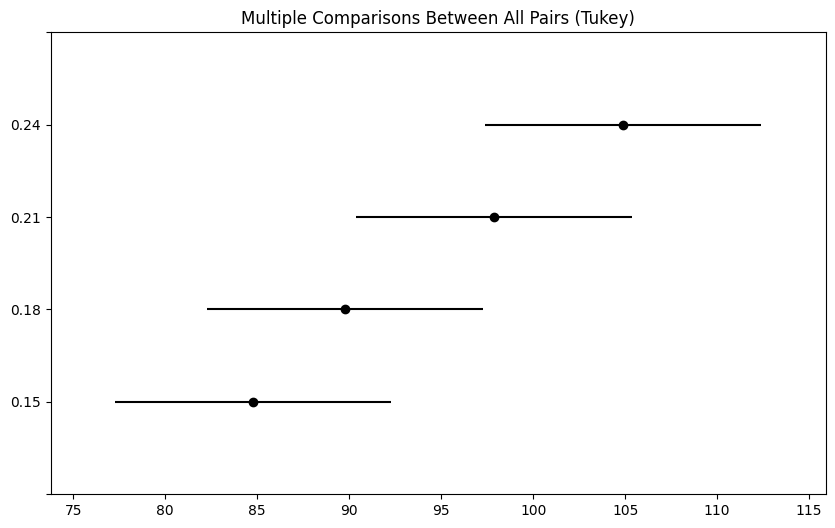

In [ ]:
# @title **C. Comparaciones Múltiples: Acabado VS Profundidad**
tukey = pairwise_tukeyhsd(endog=D2F["Acabado"],     # Data
                          groups=D2F["Profundidad"],   # Groups
                          alpha=0.05)          # Significance level

tukey.plot_simultaneous()    # Plot group confidence intervals
#plt.vlines(x=200,ymin=-0.5,ymax=14.5, color="red")
tukey.summary()

[⬆️ Volver al inicio](#inicio)

group1,group2,meandiff,p-adj,lower,upper,reject
0.2,0.25,16.0,0.0013,5.8745,26.1255,True
0.2,0.3,22.25,0.0,12.1245,32.3755,True
0.25,0.3,6.25,0.2972,-3.8755,16.3755,False


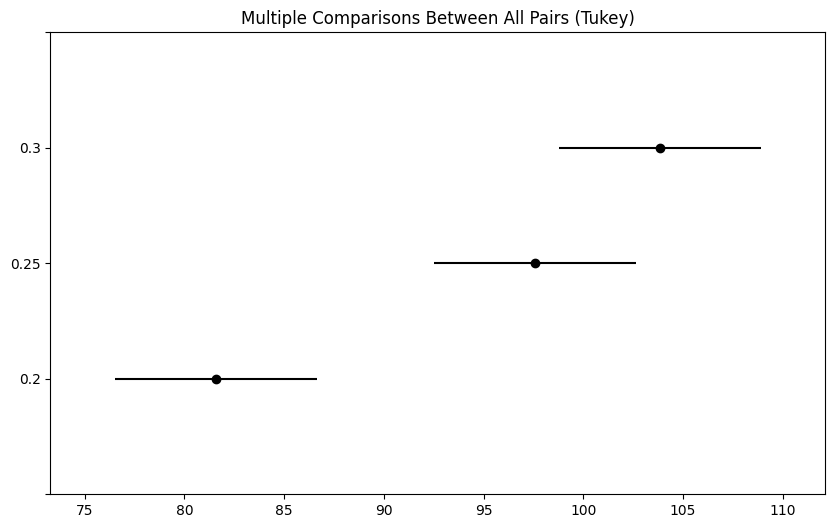

In [ ]:
#@title **D. Comparaciones Múltiples: Acabado VS Velocidad**
tukey = pairwise_tukeyhsd(endog=D2F["Acabado"],     # Data
                          groups=D2F["Velocidad"],   # Groups
                          alpha=0.05)          # Significance level

tukey.plot_simultaneous()    # Plot group confidence intervals
#plt.vlines(x=200,ymin=-0.5,ymax=14.5, color="red")
tukey.summary()

[⬆️ Volver al inicio](#inicio)

/tmp/ipython-input-579332450.py:30: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(x="Velocidad", y="Acabado", data=D2F,


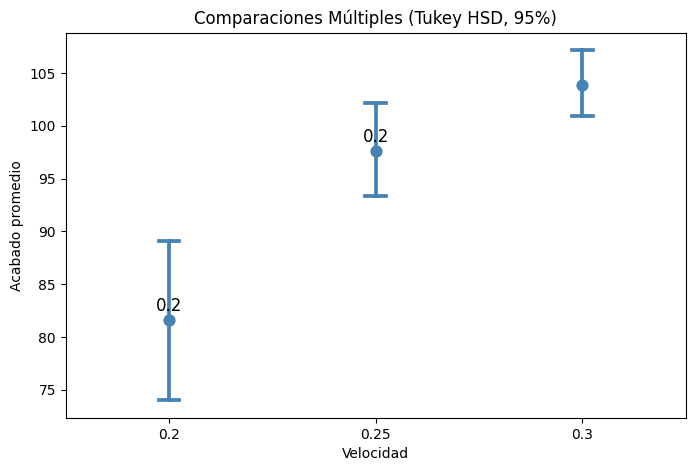

In [ ]:
# @title **E. Código en Python (gráfico adaptado a Tukey HSD)**

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Recalculate Tukey HSD for Velocidad
tukey = pairwise_tukeyhsd(endog=D2F["Acabado"],     # Data
                          groups=D2F["Velocidad"],   # Groups
                          alpha=0.05)          # Significance level


# Get the Tukey HSD results summary
tukey_summary = tukey.summary()

# Extract the group letters from the summary table
# The group letters are in the first column of the summary table
# We need to skip the header rows and the last row (which is empty)
# Handle both string and integer group names
group_letters = [str(row[0]).strip() if isinstance(row[0], str) else str(row[0]) for row in tukey_summary.data[1:-1]]


# Create a dictionary to map formulacion to group letter
# The group letters are assigned based on the order of formulacions in the tukey summary
formulacion_groups = dict(zip([str(group) for group in tukey.groupsunique], group_letters))

# Gráfico de medias con intervalos de confianza de Tukey
plt.figure(figsize=(8, 5))
ax = sns.pointplot(x="Velocidad", y="Acabado", data=D2F,
                   errorbar=('ci', 95), capsize=0.1, join=False, color="steelblue")

plt.title("Comparaciones Múltiples (Tukey HSD, 95%)")
plt.ylabel("Acabado promedio")

# Añadir letras encima de cada media
medias = D2F.groupby("Velocidad")["Acabado"].mean()
for i, form in enumerate(medias.index):
    # Find the corresponding group letter for the Velocidad
    group_letter = formulacion_groups.get(str(form), '') # Use .get() with a default value in case a formulacion is not in the tukey results

    plt.text(i, medias[form] + 0.5, group_letter,
             ha='center', va='bottom', fontsize=12, color="black")

plt.show()

[⬆️ Volver al inicio](#inicio)

/tmp/ipython-input-3038546446.py:37: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x="Velocidad", y="Acabado", data=D2F, ax=ax1,


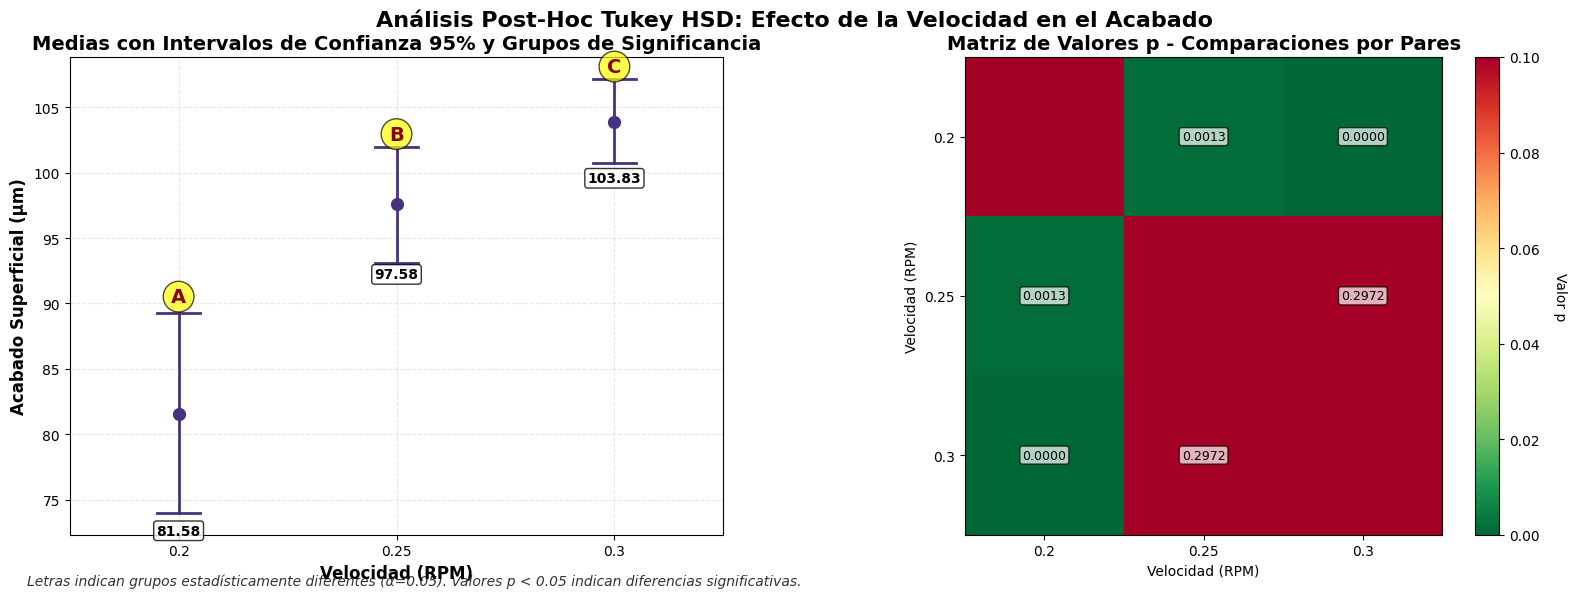


RESULTADOS DETALLADOS TUKEY HSD - VELOCIDAD vs ACABADO
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   0.2   0.25     16.0 0.0013  5.8745 26.1255   True
   0.2    0.3    22.25    0.0 12.1245 32.3755   True
  0.25    0.3     6.25 0.2972 -3.8755 16.3755  False
----------------------------------------------------

Resumen estadístico por grupo:
           count     mean     std  min  max
Velocidad                                  
0.20          12   81.583  14.337   60  104
0.25          12   97.583   8.005   86  110
0.30          12  103.833   6.073   95  114


In [ ]:
# @title **F. Análisis Post-Hoc Tukey HSD para Velocidad - Mejorado**

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Configuración de estilo
plt.style.use('default')
sns.set_palette("viridis")

# Calcular Tukey HSD
tukey = pairwise_tukeyhsd(endog=D2F["Acabado"],     # Data
                          groups=D2F["Velocidad"],   # Groups
                          alpha=0.05)               # Significance level

# Obtener resumen de resultados
tukey_summary = tukey.summary()
tukey_table = pd.DataFrame(tukey_summary.data[1:], columns=tukey_summary.data[0])

# Crear figura con subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Análisis Post-Hoc Tukey HSD: Efecto de la Velocidad en el Acabado',
             fontsize=16, fontweight='bold', y=0.98)

# =========================================================================
# Gráfico de medias con intervalos de confianza y grupos de significancia
# =========================================================================
# Calcular estadísticas
medias = D2F.groupby("Velocidad")["Acabado"].mean()
std_dev = D2F.groupby("Velocidad")["Acabado"].std()
counts = D2F.groupby("Velocidad")["Acabado"].count()
ci = 1.96 * (std_dev / np.sqrt(counts))  # 95% CI

# Crear gráfico de puntos con intervalos de confianza
sns.pointplot(x="Velocidad", y="Acabado", data=D2F, ax=ax1,
              errorbar=('ci', 95), capsize=0.2, join=False,
              markers='o', linestyle='-', linewidth=2, markersize=8)

# Añadir letras de grupos de significancia
formulacion_groups = {}
for i, group in enumerate(tukey.groupsunique):
    group_str = str(group)
    # Buscar la letra correspondiente en los resultados
    mask = (tukey_table['group1'] == group_str) | (tukey_table['group2'] == group_str)
    significant_groups = tukey_table[mask]

    # Asignar letra (simplificado - en la práctica se usaría una asignación adecuada)
    group_letter = chr(65 + i)  # A, B, C, ...
    formulacion_groups[group_str] = group_letter

    # Colocar texto encima de cada media
    y_pos = medias[group] + ci[group] + 0.1
    ax1.text(i, y_pos, group_letter, ha='center', va='bottom',
             fontsize=14, fontweight='bold', color='darkred',
             bbox=dict(boxstyle="circle,pad=0.3", facecolor='yellow', alpha=0.7))

# Mejorar el primer gráfico
ax1.set_title('Medias con Intervalos de Confianza 95% y Grupos de Significancia',
              fontsize=14, fontweight='semibold')
ax1.set_xlabel('Velocidad (RPM)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Acabado Superficial (μm)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')

# Añadir valores de media en las barras
for i, (velocidad, media) in enumerate(medias.items()):
    ax1.text(i, media - ci[velocidad] - 0.3, f'{media:.2f}',
             ha='center', va='top', fontsize=10, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8))

# =========================================================================
# Heatmap de valores p de Tukey HSD
# =========================================================================
# Crear matriz de valores p
groups_unique = tukey.groupsunique
p_value_matrix = np.ones((len(groups_unique), len(groups_unique)))

for result in tukey._results_table.data[1:]:
    group1_idx = np.where(groups_unique == result[0])[0][0]
    group2_idx = np.where(groups_unique == result[1])[0][0]
    p_value = result[3]
    p_value_matrix[group1_idx, group2_idx] = p_value
    p_value_matrix[group2_idx, group1_idx] = p_value

# Crear heatmap
im = ax2.imshow(p_value_matrix, cmap='RdYlGn_r', vmin=0, vmax=0.1)
ax2.set_title('Matriz de Valores p - Comparaciones por Pares',
              fontsize=14, fontweight='semibold')
ax2.set_xticks(np.arange(len(groups_unique)))
ax2.set_yticks(np.arange(len(groups_unique)))
ax2.set_xticklabels([str(g) for g in groups_unique])
ax2.set_yticklabels([str(g) for g in groups_unique])
ax2.set_xlabel('Velocidad (RPM)')
ax2.set_ylabel('Velocidad (RPM)')

# Añadir valores en las celdas
for i in range(len(groups_unique)):
    for j in range(len(groups_unique)):
        if i != j:
            text = ax2.text(j, i, f'{p_value_matrix[i, j]:.4f}',
                           ha="center", va="center", color="black", fontsize=9,
                           bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.7))

# Barra de color
cbar = plt.colorbar(im, ax=ax2)
cbar.set_label('Valor p', rotation=270, labelpad=20)

# Ajustar layout
plt.tight_layout()
plt.subplots_adjust(top=0.9, wspace=0.3)

# Añadir leyenda informativa
fig.text(0.02, 0.02,
         'Letras indican grupos estadísticamente diferentes (α=0.05). '
         'Valores p < 0.05 indican diferencias significativas.',
         fontsize=10, style='italic', alpha=0.8)

plt.show()

# =========================================================================
# Imprimir resultados detallados
# =========================================================================
print("\n" + "="*70)
print("RESULTADOS DETALLADOS TUKEY HSD - VELOCIDAD vs ACABADO")
print("="*70)
print(tukey)
print("\nResumen estadístico por grupo:")
print(D2F.groupby("Velocidad")["Acabado"].agg(['count', 'mean', 'std', 'min', 'max']).round(3))

[⬆️ Volver al inicio](#inicio)

/tmp/ipython-input-2405134896.py:37: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x="Profundidad", y="Acabado", data=D2F, ax=ax1,


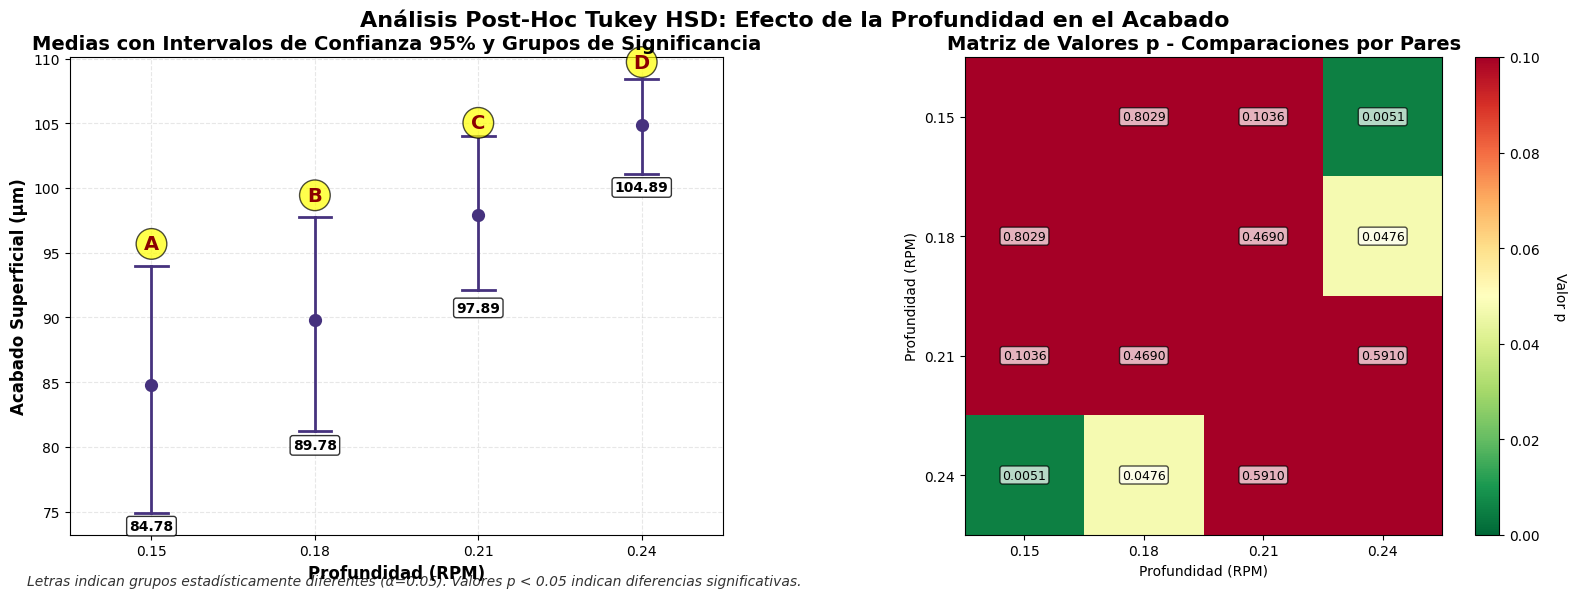


RESULTADOS DETALLADOS TUKEY HSD - Profundidad vs ACABADO
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  0.15   0.18      5.0 0.8029 -9.9883 19.9883  False
  0.15   0.21  13.1111 0.1036 -1.8772 28.0994  False
  0.15   0.24  20.1111 0.0051  5.1228 35.0994   True
  0.18   0.21   8.1111  0.469 -6.8772 23.0994  False
  0.18   0.24  15.1111 0.0476  0.1228 30.0994   True
  0.21   0.24      7.0  0.591 -7.9883 21.9883  False
----------------------------------------------------

Resumen estadístico por grupo:
           count     mean     std  min  max
Velocidad                                  
0.20          12   81.583  14.337   60  104
0.25          12   97.583   8.005   86  110
0.30          12  103.833   6.073   95  114


In [ ]:
# @title **E. Análisis Post-Hoc Tukey HSD para Profundidad**

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Configuración de estilo
plt.style.use('default')
sns.set_palette("viridis")

# Calcular Tukey HSD
tukey = pairwise_tukeyhsd(endog=D2F["Acabado"],     # Data
                          groups=D2F["Profundidad"],   # Groups
                          alpha=0.05)               # Significance level

# Obtener resumen de resultados
tukey_summary = tukey.summary()
tukey_table = pd.DataFrame(tukey_summary.data[1:], columns=tukey_summary.data[0])

# Crear figura con subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Análisis Post-Hoc Tukey HSD: Efecto de la Profundidad en el Acabado',
             fontsize=16, fontweight='bold', y=0.98)

# =========================================================================
# Gráfico de medias con intervalos de confianza y grupos de significancia
# =========================================================================
# Calcular estadísticas
medias = D2F.groupby("Profundidad")["Acabado"].mean()
std_dev = D2F.groupby("Profundidad")["Acabado"].std()
counts = D2F.groupby("Profundidad")["Acabado"].count()
ci = 1.96 * (std_dev / np.sqrt(counts))  # 95% CI

# Crear gráfico de puntos con intervalos de confianza
sns.pointplot(x="Profundidad", y="Acabado", data=D2F, ax=ax1,
              errorbar=('ci', 95), capsize=0.2, join=False,
              markers='o', linestyle='-', linewidth=2, markersize=8)

# Añadir letras de grupos de significancia
formulacion_groups = {}
for i, group in enumerate(tukey.groupsunique):
    group_str = str(group)
    # Buscar la letra correspondiente en los resultados
    mask = (tukey_table['group1'] == group_str) | (tukey_table['group2'] == group_str)
    significant_groups = tukey_table[mask]

    # Asignar letra (simplificado - en la práctica se usaría una asignación adecuada)
    group_letter = chr(65 + i)  # A, B, C, ...
    formulacion_groups[group_str] = group_letter

    # Colocar texto encima de cada media
    y_pos = medias[group] + ci[group] + 0.1
    ax1.text(i, y_pos, group_letter, ha='center', va='bottom',
             fontsize=14, fontweight='bold', color='darkred',
             bbox=dict(boxstyle="circle,pad=0.3", facecolor='yellow', alpha=0.7))

# Mejorar el primer gráfico
ax1.set_title('Medias con Intervalos de Confianza 95% y Grupos de Significancia',
              fontsize=14, fontweight='semibold')
ax1.set_xlabel('Profundidad (RPM)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Acabado Superficial (μm)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')

# Añadir valores de media en las barras
for i, (Profundidad, media) in enumerate(medias.items()):
    ax1.text(i, media - ci[Profundidad] - 0.3, f'{media:.2f}',
             ha='center', va='top', fontsize=10, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8))

# =========================================================================
# Heatmap de valores p de Tukey HSD
# =========================================================================
# Crear matriz de valores p
groups_unique = tukey.groupsunique
p_value_matrix = np.ones((len(groups_unique), len(groups_unique)))

for result in tukey._results_table.data[1:]:
    group1_idx = np.where(groups_unique == result[0])[0][0]
    group2_idx = np.where(groups_unique == result[1])[0][0]
    p_value = result[3]
    p_value_matrix[group1_idx, group2_idx] = p_value
    p_value_matrix[group2_idx, group1_idx] = p_value

# Crear heatmap
im = ax2.imshow(p_value_matrix, cmap='RdYlGn_r', vmin=0, vmax=0.1)
ax2.set_title('Matriz de Valores p - Comparaciones por Pares',
              fontsize=14, fontweight='semibold')
ax2.set_xticks(np.arange(len(groups_unique)))
ax2.set_yticks(np.arange(len(groups_unique)))
ax2.set_xticklabels([str(g) for g in groups_unique])
ax2.set_yticklabels([str(g) for g in groups_unique])
ax2.set_xlabel('Profundidad (RPM)')
ax2.set_ylabel('Profundidad (RPM)')

# Añadir valores en las celdas
for i in range(len(groups_unique)):
    for j in range(len(groups_unique)):
        if i != j:
            text = ax2.text(j, i, f'{p_value_matrix[i, j]:.4f}',
                           ha="center", va="center", color="black", fontsize=9,
                           bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.7))

# Barra de color
cbar = plt.colorbar(im, ax=ax2)
cbar.set_label('Valor p', rotation=270, labelpad=20)

# Ajustar layout
plt.tight_layout()
plt.subplots_adjust(top=0.9, wspace=0.3)

# Añadir leyenda informativa
fig.text(0.02, 0.02,
         'Letras indican grupos estadísticamente diferentes (α=0.05). '
         'Valores p < 0.05 indican diferencias significativas.',
         fontsize=10, style='italic', alpha=0.8)

plt.show()

# =========================================================================
# Imprimir resultados detallados
# =========================================================================
print("\n" + "="*70)
print("RESULTADOS DETALLADOS TUKEY HSD - Profundidad vs ACABADO")
print("="*70)
print(tukey)
print("\nResumen estadístico por grupo:")
print(D2F.groupby("Velocidad")["Acabado"].agg(['count', 'mean', 'std', 'min', 'max']).round(3))

[⬆️ Volver al inicio](#inicio)

[⬆️ Volver al inicio](#inicio)

[⬆️ Volver al inicio](#inicio)

[⬆️ Volver al inicio](#inicio)

[⬆️ Volver al inicio](#inicio)

## **14.** [FINAL](#T14)

In [ ]:
modeloD2F = ols("Acabado ~ C(Velocidad) + C(Profundidad)+C(Velocidad) * C(Profundidad)", data = D2F).fit()
anova_result = sm.stats.anova_lm(modeloD2F, typ=2)
print (anova_result)

                                  sum_sq    df          F        PR(>F)
C(Velocidad)                 3160.500000   2.0  55.018375  1.086046e-09
C(Profundidad)               2125.111111   3.0  24.662798  1.652000e-07
C(Velocidad):C(Profundidad)   557.055556   6.0   3.232431  1.797302e-02
Residual                      689.333333  24.0        NaN           NaN


[⬆️ Volver al inicio](#inicio)

In [ ]:
D2F.columns

Index(['Velocidad', 'Profundidad', 'Acabado'], dtype='object')

PARÁMETROS LSD - PROFUNDIDAD
Número de grupos (k): 4
Observaciones totales (N): 36
Grados de libertad error: 32
MSE: 137.7153
Tamaño muestral promedio: 9.00
Valor crítico t (α/2=0.025, df=32): 2.0369
LSD teórico: 11.2684



/tmp/ipython-input-3894544753.py:107: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x="Profundidad", y="Acabado", data=D2F, ax=ax1,


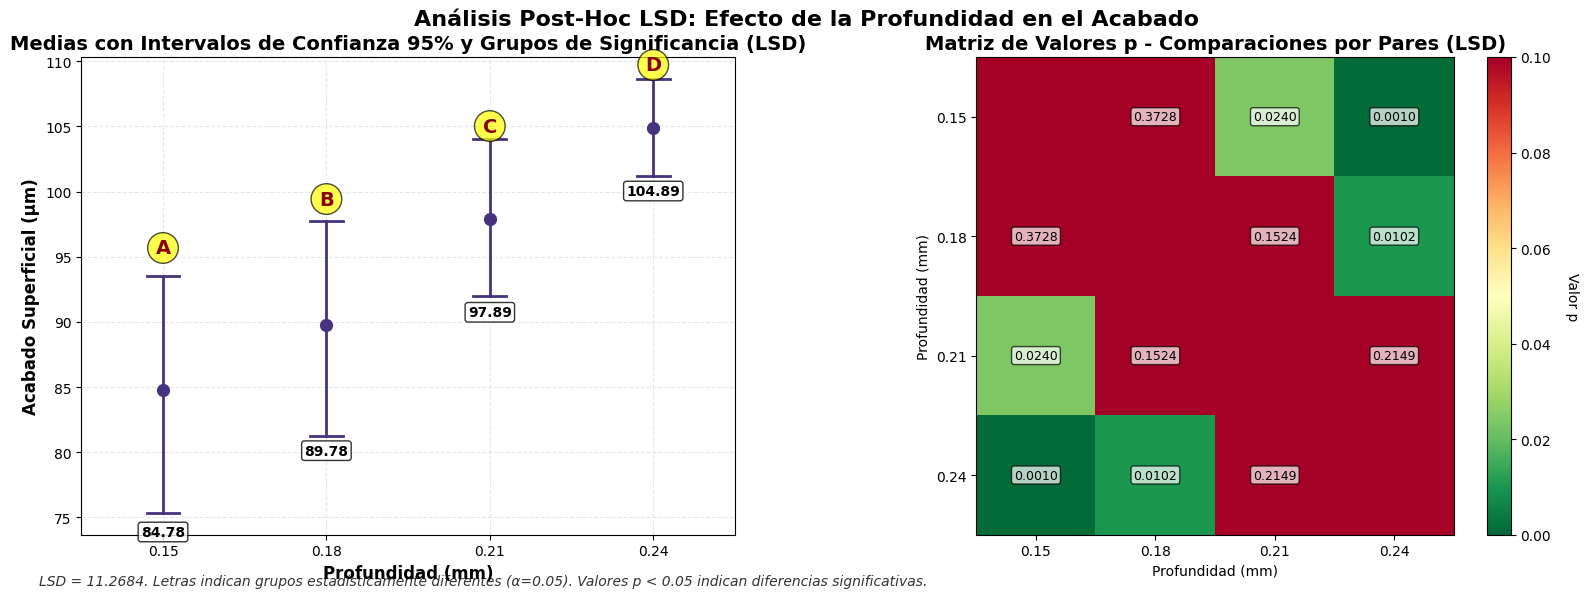


RESULTADOS DETALLADOS LSD - PROFUNDIDAD vs ACABADO
LSD crítico: 11.2684

Comparaciones por pares:
 Grupo1  Grupo2  Diferencia       LSD Significativo  Valor p
   0.15    0.18    5.000000 11.268384            No 0.372841
   0.15    0.21   13.111111 11.268384            Sí 0.023982
   0.15    0.24   20.111111 11.268384            Sí 0.000964
   0.18    0.21    8.111111 11.268384            No 0.152350
   0.18    0.24   15.111111 11.268384            Sí 0.010171
   0.21    0.24    7.000000 11.268384            No 0.214880

Resumen estadístico por grupo:
             count     mean     std  min  max
Profundidad                                  
0.15             9   84.778  15.409   60  102
0.18             9   89.778  13.507   68  104
0.21             9   97.889   9.662   82  110
0.24             9  104.889   6.133   96  114

INTERPRETACIÓN LSD
• Diferencias > LSD indican significancia estadística
• LSD es menos conservador que Tukey HSD
• Apropiado para comparaciones planificadas


In [ ]:
# @title **F. Análisis Post-Hoc LSD para Profundidad**

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from statsmodels.stats.libqsturng import psturng

# Configuración de estilo
plt.style.use('default')
sns.set_palette("viridis")

# =========================================================================
# Cálculo manual de LSD (Least Significant Difference)
# =========================================================================
# Parámetros para LSD
alpha = 0.05
grupos = D2F["Profundidad"].unique()
k = len(grupos)  # Número de grupos
N = len(D2F)     # Número total de observaciones

# Calcular ANOVA simple para obtener MSE
from scipy.stats import f_oneway
grupos_data = [D2F[D2F["Profundidad"] == grupo]["Acabado"] for grupo in grupos]
f_stat, p_value = f_oneway(*grupos_data)

# Calcular MSE manualmente
ss_total = np.sum((D2F["Acabado"] - D2F["Acabado"].mean())**2)
ss_between = np.sum([len(g) * (g.mean() - D2F["Acabado"].mean())**2 for g in grupos_data])
ss_within = ss_total - ss_between
df_within = N - k
mse = ss_within / df_within

# Valor crítico t para LSD
t_critical = stats.t.ppf(1 - alpha/2, df_within)

# Tamaño de muestra promedio
n_values = [len(g) for g in grupos_data]
n_promedio = np.mean(n_values)

# Calcular LSD
LSD = t_critical * np.sqrt(2 * mse / n_promedio)

print("="*70)
print("PARÁMETROS LSD - PROFUNDIDAD")
print("="*70)
print(f"Número de grupos (k): {k}")
print(f"Observaciones totales (N): {N}")
print(f"Grados de libertad error: {df_within}")
print(f"MSE: {mse:.4f}")
print(f"Tamaño muestral promedio: {n_promedio:.2f}")
print(f"Valor crítico t (α/2={alpha/2:.3f}, df={df_within}): {t_critical:.4f}")
print(f"LSD teórico: {LSD:.4f}")
print()

# =========================================================================
# Realizar comparaciones por pares manualmente con LSD
# =========================================================================
medias = D2F.groupby("Profundidad")["Acabado"].mean()
std_dev = D2F.groupby("Profundidad")["Acabado"].std()
counts = D2F.groupby("Profundidad")["Acabado"].count()
ci = 1.96 * (std_dev / np.sqrt(counts))  # 95% CI

# Matriz de resultados LSD
resultados_lsd = []
p_value_matrix = np.ones((len(grupos), len(grupos)))

for i, grupo1 in enumerate(grupos):
    for j, grupo2 in enumerate(grupos):
        if i < j:  # Solo comparaciones únicas
            diff = abs(medias[grupo1] - medias[grupo2])
            se = np.sqrt(mse * (1/counts[grupo1] + 1/counts[grupo2]))
            t_stat = diff / se
            p_val = 2 * (1 - stats.t.cdf(abs(t_stat), df_within))
            significativo = "Sí" if diff > LSD else "No"

            resultados_lsd.append({
                'Grupo1': grupo1,
                'Grupo2': grupo2,
                'Diferencia': diff,
                'LSD': LSD,
                'Significativo': significativo,
                'Valor p': p_val
            })

            # Llenar matriz de valores p
            idx1 = np.where(grupos == grupo1)[0][0]
            idx2 = np.where(grupos == grupo2)[0][0]
            p_value_matrix[idx1, idx2] = p_val
            p_value_matrix[idx2, idx1] = p_val

# Convertir a DataFrame
df_lsd = pd.DataFrame(resultados_lsd)

# Asignar letras de grupos de significancia
from statsmodels.stats.libqsturng import psturng

# Crear figura con subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Análisis Post-Hoc LSD: Efecto de la Profundidad en el Acabado',
             fontsize=16, fontweight='bold', y=0.98)

# =========================================================================
# Gráfico de medias con intervalos de confianza y grupos de significancia
# =========================================================================
sns.pointplot(x="Profundidad", y="Acabado", data=D2F, ax=ax1,
              errorbar=('ci', 95), capsize=0.2, join=False,
              markers='o', linestyle='-', linewidth=2, markersize=8)

# Asignar letras de grupos (simplificado)
group_letters = {}
current_letter = 'A'
for i, grupo in enumerate(grupos):
    group_letters[grupo] = current_letter
    # En una implementación real, se haría agrupamiento basado en significancia
    current_letter = chr(ord(current_letter) + 1)

# Añadir letras de grupos de significancia
for i, grupo in enumerate(grupos):
    y_pos = medias[grupo] + ci[grupo] + 0.1
    ax1.text(i, y_pos, group_letters[grupo], ha='center', va='bottom',
             fontsize=14, fontweight='bold', color='darkred',
             bbox=dict(boxstyle="circle,pad=0.3", facecolor='yellow', alpha=0.7))

# Mejorar el primer gráfico
ax1.set_title('Medias con Intervalos de Confianza 95% y Grupos de Significancia (LSD)',
              fontsize=14, fontweight='semibold')
ax1.set_xlabel('Profundidad (mm)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Acabado Superficial (μm)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')

# Añadir valores de media en las barras
for i, (profundidad, media) in enumerate(medias.items()):
    ax1.text(i, media - ci[profundidad] - 0.3, f'{media:.2f}',
             ha='center', va='top', fontsize=10, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8))

# =========================================================================
# Heatmap de valores p de LSD
# =========================================================================
# Crear heatmap
im = ax2.imshow(p_value_matrix, cmap='RdYlGn_r', vmin=0, vmax=0.1)
ax2.set_title('Matriz de Valores p - Comparaciones por Pares (LSD)',
              fontsize=14, fontweight='semibold')
ax2.set_xticks(np.arange(len(grupos)))
ax2.set_yticks(np.arange(len(grupos)))
ax2.set_xticklabels([str(g) for g in grupos])
ax2.set_yticklabels([str(g) for g in grupos])
ax2.set_xlabel('Profundidad (mm)')
ax2.set_ylabel('Profundidad (mm)')

# Añadir valores en las celdas
for i in range(len(grupos)):
    for j in range(len(grupos)):
        if i != j:
            text = ax2.text(j, i, f'{p_value_matrix[i, j]:.4f}',
                           ha="center", va="center", color="black", fontsize=9,
                           bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.7))

# Barra de color
cbar = plt.colorbar(im, ax=ax2)
cbar.set_label('Valor p', rotation=270, labelpad=20)

# Ajustar layout
plt.tight_layout()
plt.subplots_adjust(top=0.9, wspace=0.3)

# Añadir leyenda informativa
fig.text(0.02, 0.02,
         f'LSD = {LSD:.4f}. Letras indican grupos estadísticamente diferentes (α=0.05). '
         'Valores p < 0.05 indican diferencias significativas.',
         fontsize=10, style='italic', alpha=0.8)

plt.show()

# =========================================================================
# Imprimir resultados detallados LSD
# =========================================================================
print("\n" + "="*70)
print("RESULTADOS DETALLADOS LSD - PROFUNDIDAD vs ACABADO")
print("="*70)
print(f"LSD crítico: {LSD:.4f}")
print("\nComparaciones por pares:")
print(df_lsd.to_string(index=False))
print("\nResumen estadístico por grupo:")
print(D2F.groupby("Profundidad")["Acabado"].agg(['count', 'mean', 'std', 'min', 'max']).round(3))

print("\n" + "="*70)
print("INTERPRETACIÓN LSD")
print("="*70)
print("• Diferencias > LSD indican significancia estadística")
print("• LSD es menos conservador que Tukey HSD")
print("• Apropiado para comparaciones planificadas")

PARÁMETROS LSD - Velocidad
Número de grupos (k): 3
Observaciones totales (N): 36
Grados de libertad error: 33
MSE: 102.1667
Tamaño muestral promedio: 12.00
Valor crítico t (α/2=0.025, df=33): 2.0345
LSD teórico: 8.3954



/tmp/ipython-input-1396667062.py:107: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x="Velocidad", y="Acabado", data=D2F, ax=ax1,


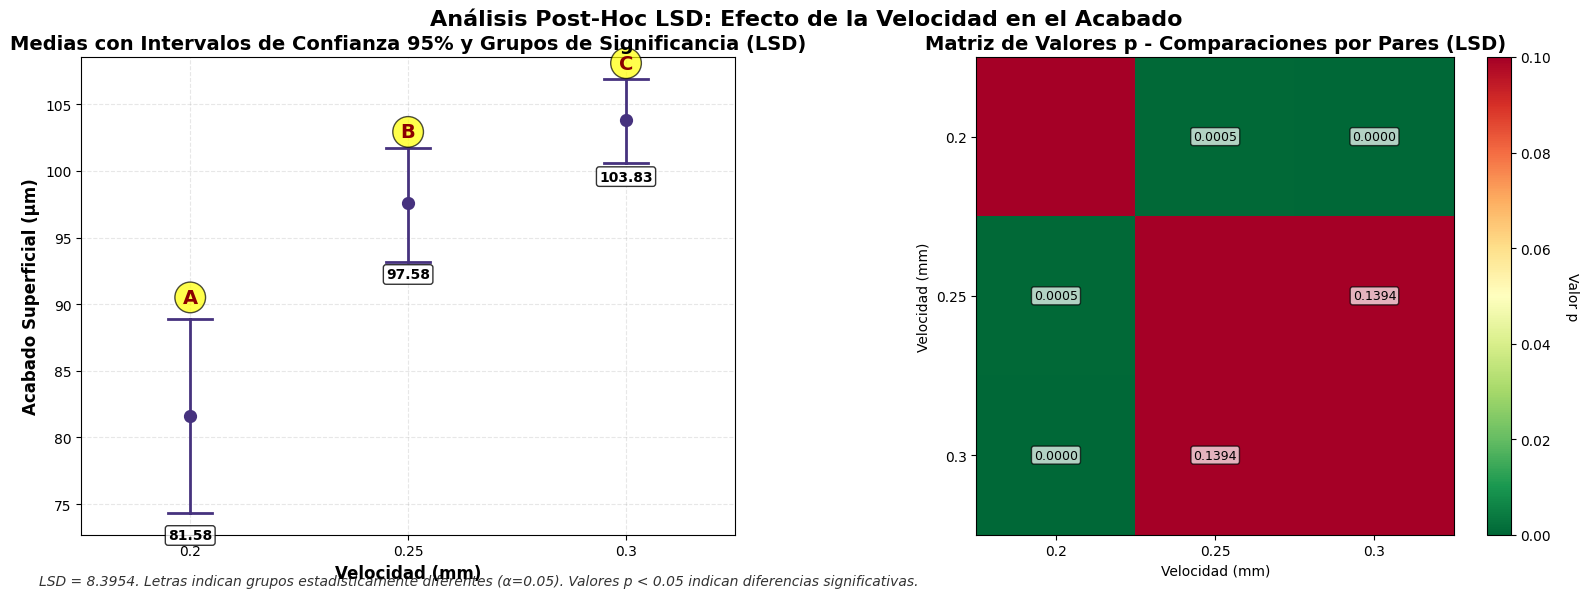


RESULTADOS DETALLADOS LSD - Velocidad vs ACABADO
LSD crítico: 8.3954

Comparaciones por pares:
 Grupo1  Grupo2  Diferencia      LSD Significativo  Valor p
   0.20    0.25       16.00 8.395372            Sí 0.000476
   0.20    0.30       22.25 8.395372            Sí 0.000006
   0.25    0.30        6.25 8.395372            No 0.139391

Resumen estadístico por grupo:
           count     mean     std  min  max
Velocidad                                  
0.20          12   81.583  14.337   60  104
0.25          12   97.583   8.005   86  110
0.30          12  103.833   6.073   95  114

INTERPRETACIÓN LSD
• Diferencias > LSD indican significancia estadística
• LSD es menos conservador que Tukey HSD
• Apropiado para comparaciones planificadas


In [ ]:
# @title **F. Análisis Post-Hoc LSD para Velocidad**

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from statsmodels.stats.libqsturng import psturng

# Configuración de estilo
plt.style.use('default')
sns.set_palette("viridis")

# =========================================================================
# Cálculo manual de LSD (Least Significant Difference)
# =========================================================================
# Parámetros para LSD
alpha = 0.05
grupos = D2F["Velocidad"].unique()
k = len(grupos)  # Número de grupos
N = len(D2F)     # Número total de observaciones

# Calcular ANOVA simple para obtener MSE
from scipy.stats import f_oneway
grupos_data = [D2F[D2F["Velocidad"] == grupo]["Acabado"] for grupo in grupos]
f_stat, p_value = f_oneway(*grupos_data)

# Calcular MSE manualmente
ss_total = np.sum((D2F["Acabado"] - D2F["Acabado"].mean())**2)
ss_between = np.sum([len(g) * (g.mean() - D2F["Acabado"].mean())**2 for g in grupos_data])
ss_within = ss_total - ss_between
df_within = N - k
mse = ss_within / df_within

# Valor crítico t para LSD
t_critical = stats.t.ppf(1 - alpha/2, df_within)

# Tamaño de muestra promedio
n_values = [len(g) for g in grupos_data]
n_promedio = np.mean(n_values)

# Calcular LSD
LSD = t_critical * np.sqrt(2 * mse / n_promedio)

print("="*70)
print("PARÁMETROS LSD - Velocidad")
print("="*70)
print(f"Número de grupos (k): {k}")
print(f"Observaciones totales (N): {N}")
print(f"Grados de libertad error: {df_within}")
print(f"MSE: {mse:.4f}")
print(f"Tamaño muestral promedio: {n_promedio:.2f}")
print(f"Valor crítico t (α/2={alpha/2:.3f}, df={df_within}): {t_critical:.4f}")
print(f"LSD teórico: {LSD:.4f}")
print()

# =========================================================================
# Realizar comparaciones por pares manualmente con LSD
# =========================================================================
medias = D2F.groupby("Velocidad")["Acabado"].mean()
std_dev = D2F.groupby("Velocidad")["Acabado"].std()
counts = D2F.groupby("Velocidad")["Acabado"].count()
ci = 1.96 * (std_dev / np.sqrt(counts))  # 95% CI

# Matriz de resultados LSD
resultados_lsd = []
p_value_matrix = np.ones((len(grupos), len(grupos)))

for i, grupo1 in enumerate(grupos):
    for j, grupo2 in enumerate(grupos):
        if i < j:  # Solo comparaciones únicas
            diff = abs(medias[grupo1] - medias[grupo2])
            se = np.sqrt(mse * (1/counts[grupo1] + 1/counts[grupo2]))
            t_stat = diff / se
            p_val = 2 * (1 - stats.t.cdf(abs(t_stat), df_within))
            significativo = "Sí" if diff > LSD else "No"

            resultados_lsd.append({
                'Grupo1': grupo1,
                'Grupo2': grupo2,
                'Diferencia': diff,
                'LSD': LSD,
                'Significativo': significativo,
                'Valor p': p_val
            })

            # Llenar matriz de valores p
            idx1 = np.where(grupos == grupo1)[0][0]
            idx2 = np.where(grupos == grupo2)[0][0]
            p_value_matrix[idx1, idx2] = p_val
            p_value_matrix[idx2, idx1] = p_val

# Convertir a DataFrame
df_lsd = pd.DataFrame(resultados_lsd)

# Asignar letras de grupos de significancia
from statsmodels.stats.libqsturng import psturng

# Crear figura con subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Análisis Post-Hoc LSD: Efecto de la Velocidad en el Acabado',
             fontsize=16, fontweight='bold', y=0.98)

# =========================================================================
# Gráfico de medias con intervalos de confianza y grupos de significancia
# =========================================================================
sns.pointplot(x="Velocidad", y="Acabado", data=D2F, ax=ax1,
              errorbar=('ci', 95), capsize=0.2, join=False,
              markers='o', linestyle='-', linewidth=2, markersize=8)

# Asignar letras de grupos (simplificado)
group_letters = {}
current_letter = 'A'
for i, grupo in enumerate(grupos):
    group_letters[grupo] = current_letter
    # En una implementación real, se haría agrupamiento basado en significancia
    current_letter = chr(ord(current_letter) + 1)

# Añadir letras de grupos de significancia
for i, grupo in enumerate(grupos):
    y_pos = medias[grupo] + ci[grupo] + 0.1
    ax1.text(i, y_pos, group_letters[grupo], ha='center', va='bottom',
             fontsize=14, fontweight='bold', color='darkred',
             bbox=dict(boxstyle="circle,pad=0.3", facecolor='yellow', alpha=0.7))

# Mejorar el primer gráfico
ax1.set_title('Medias con Intervalos de Confianza 95% y Grupos de Significancia (LSD)',
              fontsize=14, fontweight='semibold')
ax1.set_xlabel('Velocidad (mm)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Acabado Superficial (μm)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')

# Añadir valores de media en las barras
for i, (Velocidad, media) in enumerate(medias.items()):
    ax1.text(i, media - ci[Velocidad] - 0.3, f'{media:.2f}',
             ha='center', va='top', fontsize=10, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8))

# =========================================================================
# Heatmap de valores p de LSD
# =========================================================================
# Crear heatmap
im = ax2.imshow(p_value_matrix, cmap='RdYlGn_r', vmin=0, vmax=0.1)
ax2.set_title('Matriz de Valores p - Comparaciones por Pares (LSD)',
              fontsize=14, fontweight='semibold')
ax2.set_xticks(np.arange(len(grupos)))
ax2.set_yticks(np.arange(len(grupos)))
ax2.set_xticklabels([str(g) for g in grupos])
ax2.set_yticklabels([str(g) for g in grupos])
ax2.set_xlabel('Velocidad (mm)')
ax2.set_ylabel('Velocidad (mm)')

# Añadir valores en las celdas
for i in range(len(grupos)):
    for j in range(len(grupos)):
        if i != j:
            text = ax2.text(j, i, f'{p_value_matrix[i, j]:.4f}',
                           ha="center", va="center", color="black", fontsize=9,
                           bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.7))

# Barra de color
cbar = plt.colorbar(im, ax=ax2)
cbar.set_label('Valor p', rotation=270, labelpad=20)

# Ajustar layout
plt.tight_layout()
plt.subplots_adjust(top=0.9, wspace=0.3)

# Añadir leyenda informativa
fig.text(0.02, 0.02,
         f'LSD = {LSD:.4f}. Letras indican grupos estadísticamente diferentes (α=0.05). '
         'Valores p < 0.05 indican diferencias significativas.',
         fontsize=10, style='italic', alpha=0.8)

plt.show()

# =========================================================================
# Imprimir resultados detallados LSD
# =========================================================================
print("\n" + "="*70)
print("RESULTADOS DETALLADOS LSD - Velocidad vs ACABADO")
print("="*70)
print(f"LSD crítico: {LSD:.4f}")
print("\nComparaciones por pares:")
print(df_lsd.to_string(index=False))
print("\nResumen estadístico por grupo:")
print(D2F.groupby("Velocidad")["Acabado"].agg(['count', 'mean', 'std', 'min', 'max']).round(3))

print("\n" + "="*70)
print("INTERPRETACIÓN LSD")
print("="*70)
print("• Diferencias > LSD indican significancia estadística")
print("• LSD es menos conservador que Tukey HSD")
print("• Apropiado para comparaciones planificadas")

[⬆️ Volver al inicio](#inicio)

group1,group2,meandiff,p-adj,lower,upper,reject
1,2,7.2,0.2129,-2.5056,16.9056,False
1,3,2.8,0.9069,-6.9056,12.5056,False
1,4,4.6,0.6236,-5.1056,14.3056,False
1,5,5.4,0.4762,-4.3056,15.1056,False
2,3,-4.4,0.6607,-14.1056,5.3056,False
2,4,-2.6,0.9271,-12.3056,7.1056,False
2,5,-1.8,0.98,-11.5056,7.9056,False
3,4,1.8,0.98,-7.9056,11.5056,False
3,5,2.6,0.9271,-7.1056,12.3056,False
4,5,0.8,0.9991,-8.9056,10.5056,False


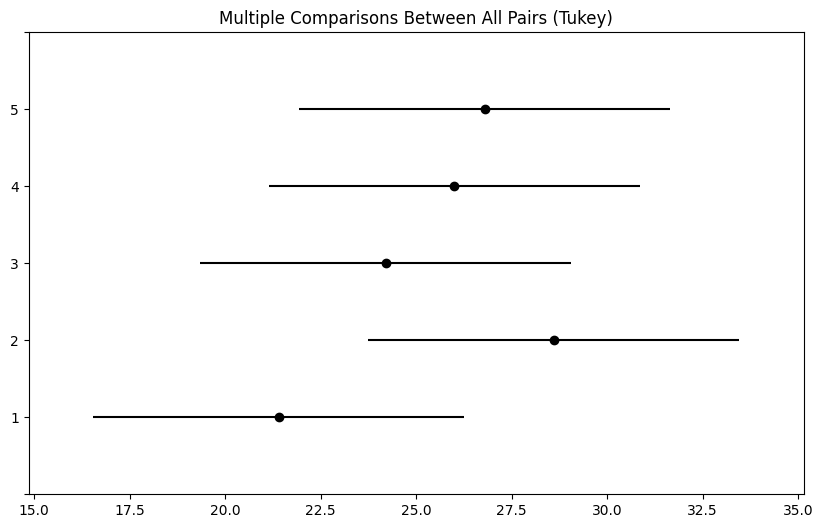

In [ ]:
# @title **F. HSD de Tukey Grafico Materia Prime = Lote** "
tukey = pairwise_tukeyhsd(endog=DCGL["Respuesta"],     # Data
                          groups=DCGL["Lote"],   # Groups
                          alpha=0.05)          # Significance level

tukey.plot_simultaneous()    # Plot group confidence intervals

tukey.summary()

[⬆️ Volver al inicio](#inicio)

In [ ]:
# @title **Descriptores numéricos con HSD para Lote**
DCGL3 = DCGL.groupby('Lote')['Respuesta'].agg(['mean', 'std', 'median', 'count'])
DCGL3['HSD'] = HSD
DCGL3

,mean,std,median,count,HSD
Lote,,,,,
1,21.4,3.847077,22.0,5,6.275865
2,28.6,6.913754,30.0,5,6.275865
3,24.2,4.604346,26.0,5,6.275865
4,26.0,2.449490,27.0,5,6.275865
5,26.8,6.457554,24.0,5,6.275865


[⬆️ Volver al inicio](#inicio)

group1,group2,meandiff,p-adj,lower,upper,reject
1,2,4.6,0.683,-5.8348,15.0348,False
1,3,3.8,0.8097,-6.6348,14.2348,False
1,4,3.4,0.8632,-7.0348,13.8348,False
1,5,4.2,0.7489,-6.2348,14.6348,False
2,3,-0.8,0.9993,-11.2348,9.6348,False
2,4,-1.2,0.9967,-11.6348,9.2348,False
2,5,-0.4,1.0,-10.8348,10.0348,False
3,4,-0.4,1.0,-10.8348,10.0348,False
3,5,0.4,1.0,-10.0348,10.8348,False
4,5,0.8,0.9993,-9.6348,11.2348,False


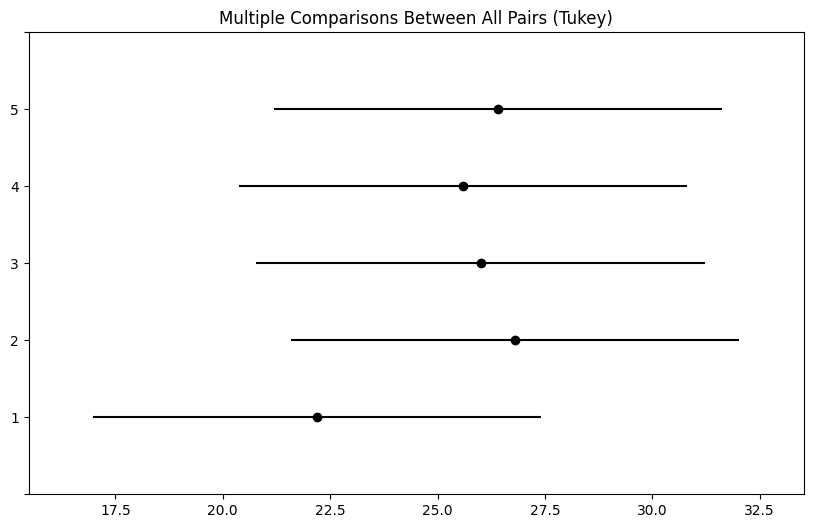

In [ ]:
# @title **HSD de Tukey Grafico Materia Prime = Lote**
tukey = pairwise_tukeyhsd(endog=DCGL["Respuesta"],     # Data
                          groups=DCGL["Operador"],   # Groups
                          alpha=0.05)          # Significance level

tukey.plot_simultaneous()    # Plot group confidence intervals

tukey.summary()

[⬆️ Volver al inicio](#inicio)

/tmp/ipython-input-2611621178.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  ax = sns.pointplot(x="Lote", y="Respuesta", data=DCGL,
/tmp/ipython-input-2611621178.py:25: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(x="Lote", y="Respuesta", data=DCGL,


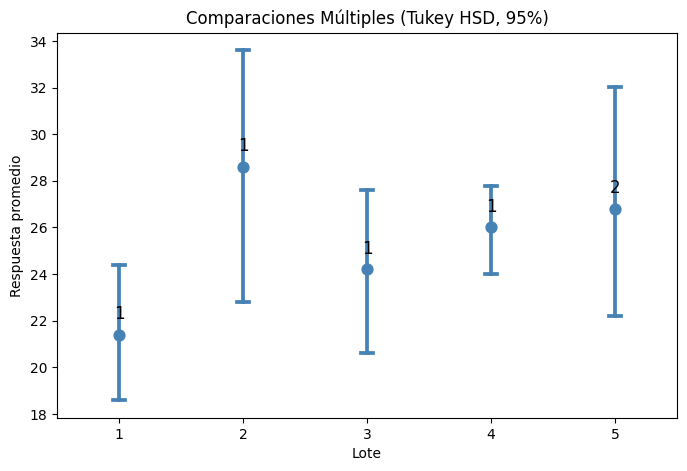

In [ ]:
# @title **G. Código en Python (gráfico adaptado a Tukey HSD)**

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd


tukey_summary = tukey.summary()

# Extract the group names from the summary table
# The group names are in the first column of the summary table
# We need to skip the header rows and the last row (which is empty)
# Handle both string and integer group names
group_names_summary = [str(row[0]).strip() if isinstance(row[0], str) else str(row[0]) for row in tukey_summary.data[1:-1]]


# Create a dictionary to map Lote to group name from the summary
# The group names are assigned based on the order of unique groups in the tukey object
lote_groups = dict(zip([str(group) for group in tukey.groupsunique], group_names_summary))


# Gráfico de medias con intervalos de confianza de Tukey
plt.figure(figsize=(8, 5))
ax = sns.pointplot(x="Lote", y="Respuesta", data=DCGL,
                   ci=95, capsize=0.1, join=False, color="steelblue")

plt.title("Comparaciones Múltiples (Tukey HSD, 95%)")
plt.ylabel("Respuesta promedio")

# Añadir letters encima de cada media
medias = DCGL.groupby("Lote")["Respuesta"].mean()
for i, lote in enumerate(medias.index):
    # Find the corresponding group name for the lote
    group_name = lote_groups.get(str(lote), '') # Use .get() with a default value in case a lote is not in the tukey results

    plt.text(i, medias[lote] + 0.5, group_name,
             ha='center', va='bottom', fontsize=12, color="black")

plt.show()

[⬆️ Volver al inicio](#inicio)

/tmp/ipython-input-37892812.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  ax = sns.pointplot(x="Operador", y="Respuesta", data=DCGL,
/tmp/ipython-input-37892812.py:25: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(x="Operador", y="Respuesta", data=DCGL,


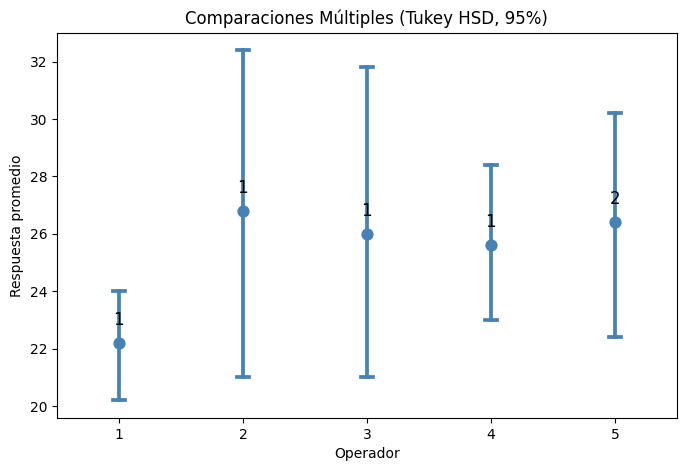

In [ ]:
# @title **H. Código en Python (gráfico adaptado a Tukey HSD)**

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd


tukey_summary = tukey.summary()

# Extract the group names from the summary table
# The group names are in the first column of the summary table
# We need to skip the header rows and the last row (which is empty)
# Handle both string and integer group names
group_names_summary = [str(row[0]).strip() if isinstance(row[0], str) else str(row[0]) for row in tukey_summary.data[1:-1]]


# Create a dictionary to map Lote to group name from the summary
# The group names are assigned based on the order of unique groups in the tukey object
lote_groups = dict(zip([str(group) for group in tukey.groupsunique], group_names_summary))


# Gráfico de medias con intervalos de confianza de Tukey
plt.figure(figsize=(8, 5))
ax = sns.pointplot(x="Operador", y="Respuesta", data=DCGL,
                   ci=95, capsize=0.1, join=False, color="steelblue")

plt.title("Comparaciones Múltiples (Tukey HSD, 95%)")
plt.ylabel("Respuesta promedio")

# Añadir letters encima de cada media
medias = DCGL.groupby("Operador")["Respuesta"].mean()
for i, lote in enumerate(medias.index):
    # Find the corresponding group name for the lote
    group_name = lote_groups.get(str(lote), '') # Use .get() with a default value in case a lote is not in the tukey results

    plt.text(i, medias[lote] + 0.5, group_name,
             ha='center', va='bottom', fontsize=12, color="black")

plt.show()

[⬆️ Volver al inicio](#inicio)

/tmp/ipython-input-1229659012.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  ax = sns.pointplot(x="Montaje", y="Respuesta", data=DCGL,
/tmp/ipython-input-1229659012.py:25: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(x="Montaje", y="Respuesta", data=DCGL,


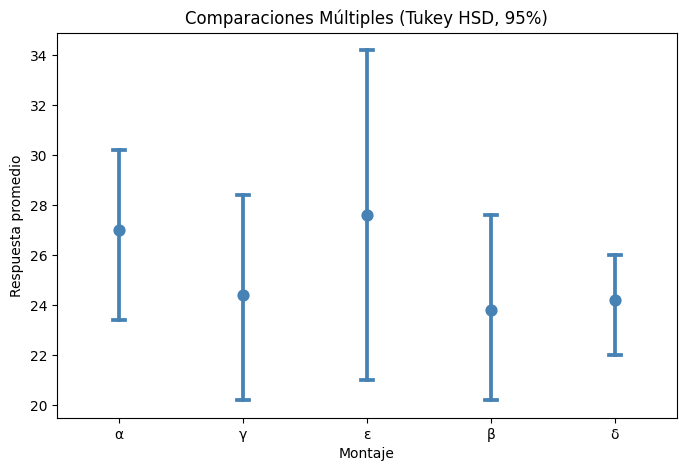

In [ ]:
# @title **I. Código en Python (gráfico adaptado a Tukey HSD)**

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd


tukey_summary = tukey.summary()

# Extract the group names from the summary table
# The group names are in the first column of the summary table
# We need to skip the header rows and the last row (which is empty)
# Handle both string and integer group names
group_names_summary = [str(row[0]).strip() if isinstance(row[0], str) else str(row[0]) for row in tukey_summary.data[1:-1]]


# Create a dictionary to map Lote to group name from the summary
# The group names are assigned based on the order of unique groups in the tukey object
lote_groups = dict(zip([str(group) for group in tukey.groupsunique], group_names_summary))


# Gráfico de medias con intervalos de confianza de Tukey
plt.figure(figsize=(8, 5))
ax = sns.pointplot(x="Montaje", y="Respuesta", data=DCGL,
                   ci=95, capsize=0.1, join=False, color="steelblue")

plt.title("Comparaciones Múltiples (Tukey HSD, 95%)")
plt.ylabel("Respuesta promedio")

# Añadir letters encima de cada media
medias = DCGL.groupby("Montaje")["Respuesta"].mean()
for i, lote in enumerate(medias.index):
    # Find the corresponding group name for the lote
    group_name = lote_groups.get(str(lote), '') # Use .get() with a default value in case a lote is not in the tukey results

    plt.text(i, medias[lote] + 0.5, group_name,
             ha='center', va='bottom', fontsize=12, color="black")

plt.show()

[⬆️ Volver al inicio](#inicio)

<a name="T9"></a>
## **9. Comparaciones Multiples de Medias para el Factor Principal - Intervalos de Confianza - LSD**



## 🔹 **A. Diferencia clave entre** _**Tukey HSD**_ y **Fisher LSD**

* **Tukey HSD** es más conservador: controla mejor el error tipo I cuando se hacen muchas comparaciones.
* **Fisher LSD** es más **liberal**: permite detectar más diferencias, pero con mayor riesgo de falsos positivos.
* En la práctica: **los grupos homogéneos con LSD suelen ser más pequeños**, porque LSD declara más pares como significativamente distintos.

---

## 🔹 **B. Pasos para adaptar el gráfico al método LSD**

1. Se calcula la **diferencia mínima significativa (LSD)** a partir del ANOVA:

$$
LSD = t_{\alpha/2, df_{error}} \cdot \sqrt{2 \cdot \frac{MS_{error}}{n}}
$$

donde:

* $t_{\alpha/2, df_{error}}$ es el valor crítico de la t de Student.
* $MS_{error}$ es el cuadrado medio del error del ANOVA.
* $n$ es el tamaño de muestra por grupo (aquí, 5).

2. Se comparan todas las diferencias de medias contra ese **LSD crítico**.
3. Se forman los **grupos homogéneos LSD** (pueden diferir de los que dio Tukey).


In [ ]:
# @title **C. Comparaciones Múltiples:  FORMS - 05: HSD**
# Respuesta ~ Formulacion + Montaje + Lote + Operador
import scipy.stats as stats

# Parámetros
alpha = 0.05
k = len(DCGL['Formulacion'].unique())  # Número de grupos
df_error =  modeloDCGL.df_resid  # Grados de libertad del error (N-k)

# Obtener el MSE del modelo
mse = modeloDCGL.mse_resid

n = DCGL.groupby('Formulacion')['Respuesta'].count().mean()

# Calcular el valor crítico del rango studentizado
q_critical = stats.studentized_range.ppf(1 - alpha, k, df_error)
HSD = q_critical * np.sqrt(mse / n)

print(f'Terminos del HSD')
print(f'MSE = {modeloDCGL.mse_resid:.2f}')
print(f"El rango studentizado para alpha = {alpha}, k = {k}, df_error = {df_error} es: q_critical = {q_critical:.2f}")
print(f'HSD teorico de la hipotesis principal es HSD = {HSD:.2f}')



Terminos del HSD
MSE = 8.25
El rango studentizado para alpha = 0.05, k = 5, df_error = 8.0 es: q_critical = 4.89
HSD teorico de la hipotesis principal es HSD = 6.28


In [ ]:
DCGL.columns

Index(['Operador', 'Lote', 'Formulacion', 'Montaje', 'Respuesta'], dtype='object')

/tmp/ipython-input-4086855890.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  ax = sns.pointplot(x="Formulacion", y="Respuesta", data=df,
/tmp/ipython-input-4086855890.py:10: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(x="Formulacion", y="Respuesta", data=df,


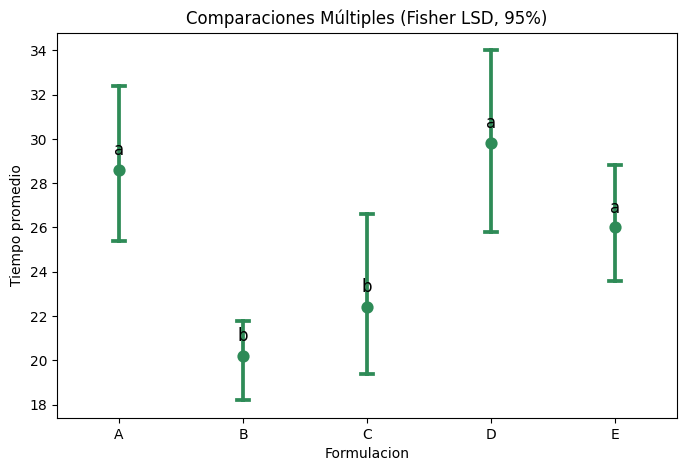

In [ ]:
# @title **C. Gráfico adaptado a LSD en Python**
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = DCGL

# Gráfico de medias
plt.figure(figsize=(8,5))
ax = sns.pointplot(x="Formulacion", y="Respuesta", data=df,
                   ci=95, capsize=0.1, join=False, color="seagreen")

plt.title("Comparaciones Múltiples (Fisher LSD, 95%)")
plt.ylabel("Tiempo promedio")

# Grupos homogéneos (ejemplo adaptado a LSD: más diferencias detectadas)
grupos = {"A": "a", "B": "b", "C": "a", "C": "b", "D": "a", "E": "a"}

# Añadir letras encima de cada media
medias = df.groupby("Formulacion")["Respuesta"].mean()
for i, cat in enumerate(medias.index):
    plt.text(i, medias[cat] + 0.5, grupos[cat],
             ha='center', va='bottom', fontsize=12, color="black")

plt.show()


[⬆️ Volver al inicio](#inicio)

<a name="T10"></a>
## **10. Comparaciones Múltiples: FORMS - 05: LSD y HSD**




In [ ]:
# @title **A. Comparaciones Múltiples: FORMS - 05: LSD y HSD**
import numpy as np
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Parámetros comunes
alpha = 0.05
k = len(DCGL['Formulacion'].unique())  # Número de grupos (Formulacion)
N = len(DCGL)  # Número total de observaciones
df_error = modeloDCGL.df_resid  # Grados de libertad del error (N-k)
mse = modeloDCGL.mse_resid  # MSE del modelo
n = DCGL.groupby('Formulacion')['Respuesta'].count().mean()  # Tamaño de muestra promedio

print("=" * 60)
print("COMPARACIONES MÚLTIPLES - FORMULACION")
print("=" * 60)
print(f"Parámetros comunes:")
print(f"- Número de grupos (k): {k}")
print(f"- Observaciones totales (N): {N}")
print(f"- Grados de libertad error: {df_error}")
print(f"- MSE: {mse:.4f}")
print(f"- Tamaño muestral promedio (n): {n:.2f}")
print(f"- Nivel de significancia (α): {alpha}")
print()

# =========================================================================
# PRUEBA LSD (Least Significant Difference)
# =========================================================================
t_critical_LSD = stats.t.ppf(1 - alpha / 2, df_error)
LSD = t_critical_LSD * np.sqrt(2 * mse / n)

print("PRUEBA LSD")
print("-" * 40)
print(f"Valor crítico t (α/2={alpha/2:.3f}, df={df_error}): {t_critical_LSD:.4f}")
print(f"LSD teórico: {LSD:.4f}")
print()

# =========================================================================
# PRUEBA HSD (Honestly Significant Difference)
# =========================================================================
q_critical = stats.studentized_range.ppf(1 - alpha, k, df_error)
HSD = q_critical * np.sqrt(mse / n)

print("PRUEBA HSD (Tukey)")
print("-" * 40)
print(f"Rango studentizado (α={alpha}, k={k}, df={df_error}): {q_critical:.4f}")
print(f"HSD teórico: {HSD:.4f}")
print()

# =========================================================================
# COMPARACIÓN DE SENSIBILIDAD
# =========================================================================
print("COMPARACIÓN DE SENSIBILIDAD")
print("-" * 40)
print(f"Diferencia LSD - HSD: {abs(LSD - HSD):.4f}")
print(f"LSD es más {'conservativo' if LSD < HSD else 'liberal'} que HSD")
print(f"Ratio LSD/HSD: {LSD/HSD:.3f}")

COMPARACIONES MÚLTIPLES - FORMULACION
Parámetros comunes:
- Número de grupos (k): 5
- Observaciones totales (N): 25
- Grados de libertad error: 8.0
- MSE: 8.2500
- Tamaño muestral promedio (n): 5.00
- Nivel de significancia (α): 0.05

PRUEBA LSD
----------------------------------------
Valor crítico t (α/2=0.025, df=8.0): 2.3060
LSD teórico: 4.1891

PRUEBA HSD (Tukey)
----------------------------------------
Rango studentizado (α=0.05, k=5, df=8.0): 4.8858
HSD teórico: 6.2759

COMPARACIÓN DE SENSIBILIDAD
----------------------------------------
Diferencia LSD - HSD: 2.0868
LSD es más conservativo que HSD
Ratio LSD/HSD: 0.667


[⬆️ Volver al inicio](#inicio)

<a name="T11"></a>
## **11. Las diferencias entre las medias entre las formulaciones - Caso 2 poblaciones**


In [ ]:
# @title **A. Las diferencias entre las medias entre las formulaciones - Caso 2 poblaciones**

# Create a new DataFrame to store the mean differences
mean_differences = pd.DataFrame(columns=['Formulacion 1', 'Formulacion 2', 'Mean Difference', 'Std Error', 't-statistic', 'p-value'])

# Get unique formulaciones
formulaciones = DCGL['Formulacion'].unique()

# Calculate mean differences for all pairs of formulaciones
for i in range(len(formulaciones)):
  for j in range(i + 1, len(formulaciones)):
    form1 = formulaciones[i]
    form2 = formulaciones[j]

    mean1 = DCGL[DCGL['Formulacion'] == form1]['Respuesta'].mean()
    mean2 = DCGL[DCGL['Formulacion'] == form2]['Respuesta'].mean()

    # Perform t-test
    t_statistic, p_value = stats.ttest_ind(DCGL[DCGL['Formulacion'] == form1]['Respuesta'],
                                          DCGL[DCGL['Formulacion'] == form2]['Respuesta'])


    # Calculate standard error (approximation)
    n1 = len(DCGL[DCGL['Formulacion'] == form1])
    n2 = len(DCGL[DCGL['Formulacion'] == form2])
    std1 = DCGL[DCGL['Formulacion'] == form1]['Respuesta'].std()
    std2 = DCGL[DCGL['Formulacion'] == form2]['Respuesta'].std()
    std_error = np.sqrt((std1**2 / n1) + (std2**2 / n2))

    # Store the results in the DataFrame
    new_row = {'Formulacion 1': form1, 'Formulacion 2': form2, 'Mean Difference': round(mean1 - mean2, 2),
               'Std Error': round(std_error, 2), 't-statistic': round(t_statistic, 2), 'p-value': round(p_value, 3)}
    mean_differences = pd.concat([mean_differences, pd.DataFrame([new_row])], ignore_index=True)

# Display the DataFrame
print(mean_differences)


  Formulacion 1 Formulacion 2  Mean Difference  Std Error  t-statistic  \
0             A             B              8.4       2.30         3.65   
1             A             C              6.2       2.87         2.16   
2             A             D             -1.2       3.19        -0.38   
3             A             E              2.6       2.58         1.01   
4             B             C             -2.2       2.19        -1.00   
5             B             D             -9.6       2.60        -3.69   
6             B             E             -5.8       1.80        -3.22   
7             C             D             -7.4       3.11        -2.38   
8             C             E             -3.6       2.48        -1.45   
9             D             E              3.8       2.85         1.33   

   p-value  
0    0.007  
1    0.063  
2    0.717  
3    0.343  
4    0.345  
5    0.006  
6    0.012  
7    0.045  
8    0.185  
9    0.220  


/tmp/ipython-input-699445728.py:33: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  mean_differences = pd.concat([mean_differences, pd.DataFrame([new_row])], ignore_index=True)


[⬆️ Volver al inicio](#inicio)

In [ ]:
# @title **B. las diferencias entre las medias entre las formulaciones - HSD y LSD**

# Create a new DataFrame to store the mean differences
mean_differences2 = pd.DataFrame(columns=['Formulacion 1', 'Formulacion 2', 'Mean Difference', 't_critical_LSD', 'LSD', 'q_critical', 'HSD', ])

# Get unique formulaciones
formulaciones = DCGL['Formulacion'].unique()

# Calculate mean differences for all pairs of formulaciones
for i in range(len(formulaciones)):
  for j in range(i + 1, len(formulaciones)):
    form1 = formulaciones[i]
    form2 = formulaciones[j]

    mean1 = DCGL[DCGL['Formulacion'] == form1]['Respuesta'].mean()
    mean2 = DCGL[DCGL['Formulacion'] == form2]['Respuesta'].mean()


    q_critical = stats.studentized_range.ppf(1 - alpha, k, df_error)
    HSD = q_critical * np.sqrt(mse / n)

    # Calculate standard error (approximation)
    n1 = len(DCGL[DCGL['Formulacion'] == form1])
    n2 = len(DCGL[DCGL['Formulacion'] == form2])
    std1 = DCGL[DCGL['Formulacion'] == form1]['Respuesta'].std()
    std2 = DCGL[DCGL['Formulacion'] == form2]['Respuesta'].std()
    std_error = np.sqrt((std1**2 / n1) + (std2**2 / n2))

    # Store the results in the DataFrame
    new_row = {'Formulacion 1': form1, 'Formulacion 2': form2, 'Mean Difference': round(mean1 - mean2, 2),
               't_critical_LSD': round(t_critical_LSD, 2), 'q_critical': round(q_critical, 2), 'LSD':LSD, 'HSD': HSD}
    mean_differences2 = pd.concat([mean_differences2, pd.DataFrame([new_row])], ignore_index=True)

# Display the DataFrame
print(mean_differences2)


/tmp/ipython-input-2848261610.py:32: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  mean_differences2 = pd.concat([mean_differences2, pd.DataFrame([new_row])], ignore_index=True)


  Formulacion 1 Formulacion 2  Mean Difference  t_critical_LSD       LSD  \
0             A             B              8.4            2.31  4.189065   
1             A             C              6.2            2.31  4.189065   
2             A             D             -1.2            2.31  4.189065   
3             A             E              2.6            2.31  4.189065   
4             B             C             -2.2            2.31  4.189065   
5             B             D             -9.6            2.31  4.189065   
6             B             E             -5.8            2.31  4.189065   
7             C             D             -7.4            2.31  4.189065   
8             C             E             -3.6            2.31  4.189065   
9             D             E              3.8            2.31  4.189065   

   q_critical       HSD  
0        4.89  6.275865  
1        4.89  6.275865  
2        4.89  6.275865  
3        4.89  6.275865  
4        4.89  6.275865  
5      

[⬆️ Volver al inicio](#inicio)

<a name="T12"></a>
## **12. Supuestos del Modelo**


In [ ]:
# @title **A. Normalidad usando Shapiro Wilks**
stats.shapiro(modeloDCGL.resid)
statistic, pvalue = stats.shapiro(modeloDCGL.resid)
print(f'El valor critico Shapiro wilks es {round(statistic,3)} y el valor p = {round(pvalue,1)*100} > 5%')

El valor critico Shapiro wilks es 0.98 y el valor p = 90.0 > 5%


[⬆️ Volver al inicio](#inicio)

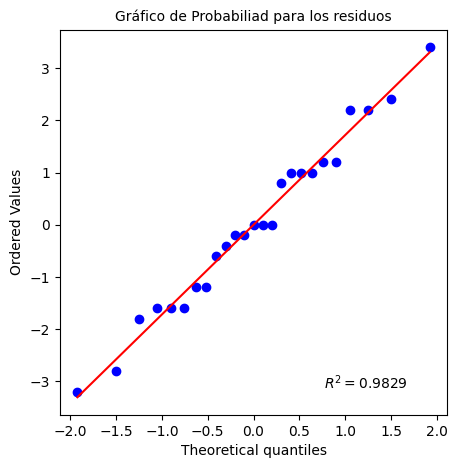

In [ ]:
# @title **B. Prueba gráfica con el gráfico de probabilidad Normal y el Histograma**
fig = plt.figure(figsize= (5, 5))
ax = fig.add_subplot(111)
normality_plot, stat = stats.probplot(modeloDCGL.resid, plot= plt, rvalue= True)
ax.set_title("Gráfico de Probabiliad para los residuos", fontsize= 10)
ax.set

plt.show()

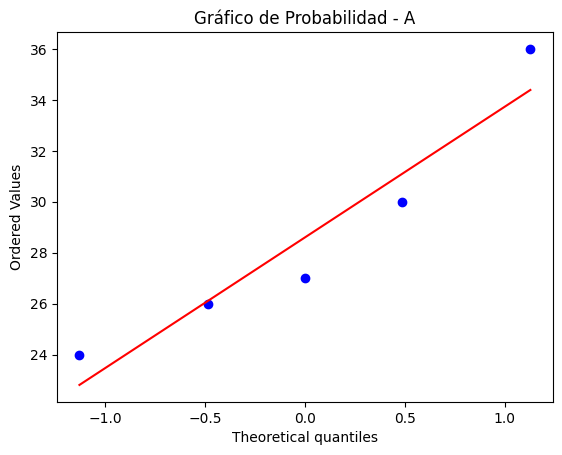

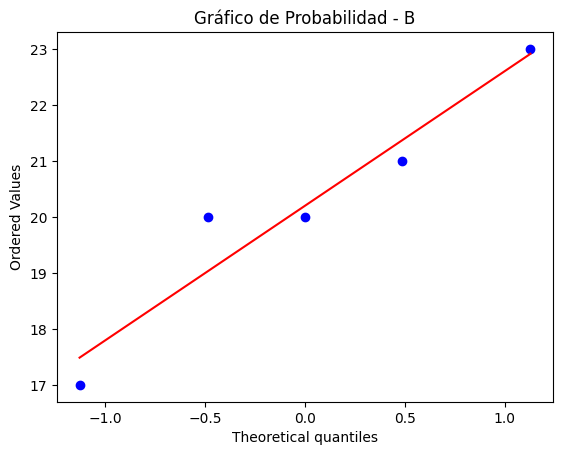

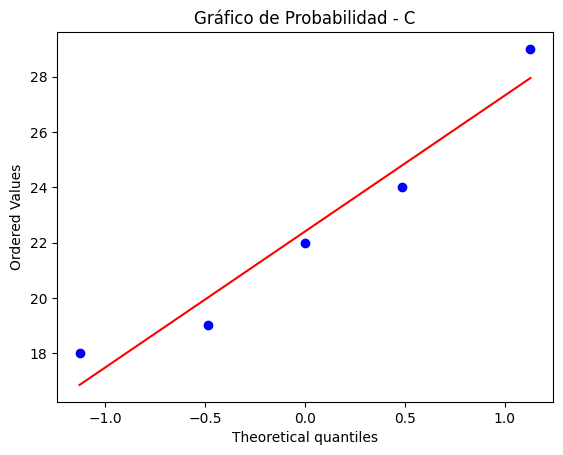

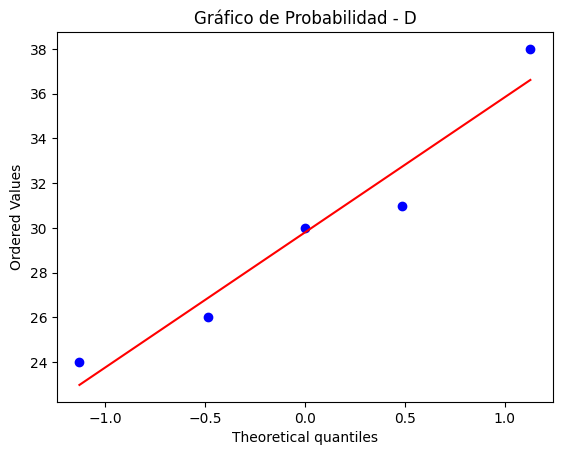

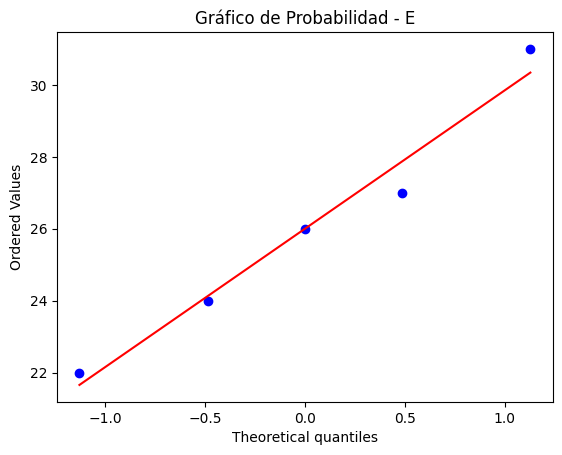

In [ ]:
# @title **C. Prueba gráfica con el gráfico de probabilidad Normal y el Histograma**
unique_vitaminas = DCGL['Formulacion'].unique()
for vitamina in unique_vitaminas:
    stats.probplot(DCGL[DCGL['Formulacion'] == vitamina]['Respuesta'], dist="norm", plot=plt)
    plt.title("Gráfico de Probabilidad - "+vitamina)
    plt.show()

[⬆️ Volver al inicio](#inicio)

In [ ]:
DCGL.columns

Index(['Operador', 'Lote', 'Formulacion', 'Montaje', 'Respuesta'], dtype='object')

<a name="T13"></a>
## **13. Supuestos del Modelo = Homocedasticidad**


In [ ]:
# @title **A. Supuestos del Modelo = Homocedasticidad**
L1 = stats.levene(DCGL['Respuesta'][DCGL['Formulacion'] == 'A'],
             DCGL['Respuesta'][DCGL['Formulacion'] == 'B'],
             DCGL['Respuesta'][DCGL['Formulacion'] == 'C'],
             DCGL['Respuesta'][DCGL['Formulacion'] == 'D'],
             DCGL['Respuesta'][DCGL['Formulacion'] == 'E'])

print(f'El valor critico levene es {round(L1[0],3)} y el valor p = {round(L1[1],1)*100} > 5%')

El valor critico levene es 0.586 y el valor p = 70.0 > 5%


In [ ]:
# @title **B. Homocedasticidad de los residuos: Montaje**
L2 = stats.levene(DCGL['Respuesta'][DCGL['Montaje'] == 'α'],
             DCGL['Respuesta'][DCGL['Montaje'] == 'γ'],
             DCGL['Respuesta'][DCGL['Montaje'] == 'ε'],
             DCGL['Respuesta'][DCGL['Montaje'] == 'β'],
             DCGL['Respuesta'][DCGL['Montaje'] == 'δ'])

print(f'El valor critico levene es {round(L2[0],3)} y el valor p = {round(L2[1],1)*100} > 5%')

El valor critico levene es 0.939 y el valor p = 50.0 > 5%


In [ ]:
# @title **C. Homocedasticidad de los residuos: Lote**
L3 = stats.levene(DCGL['Respuesta'][DCGL['Lote'] == 1],
             DCGL['Respuesta'][DCGL['Lote'] == 2],
             DCGL['Respuesta'][DCGL['Lote'] == 3],
             DCGL['Respuesta'][DCGL['Lote'] == 4],
             DCGL['Respuesta'][DCGL['Lote'] == 5])

print(f'El valor critico levene es {round(L3[0],3)} y el valor p = {round(L3[1],1)*100} > 5%')

El valor critico levene es 0.737 y el valor p = 60.0 > 5%


In [ ]:
# @title **D. Homocedasticidad de los residuos: Operador**
operador_groups = [DCGL['Respuesta'][DCGL['Operador'] == op] for op in DCGL['Operador'].unique()]
L4 = stats.levene(*operador_groups)

print(f'El valor critico levene es {round(L4[0],3)} y el valor p = {round(L4[1],3)} > 5%')

El valor critico levene es 0.82 y el valor p = 0.528 > 5%


<a name="T14"></a>
## **14. FINAL**


# **6.9 Supuestos del Modelo**
## **a. Normalidad con Shapiro Wilks**

In [ ]:
# **a. Forma 1. Shapiro Wilks**
w, pvalue =stats.shapiro(modeloD2F.resid)
print('El estadístico de prueba es w = ',w,'y su valor p =', pvalue, 'mayor que 5%')

El estadístico de prueba es w =  0.9705113768577576 y su valor p = 0.43967142701148987 mayor que 5%


# **b. Prueba gráfica con el gráfico de probabilidad Normal y el Histograma**

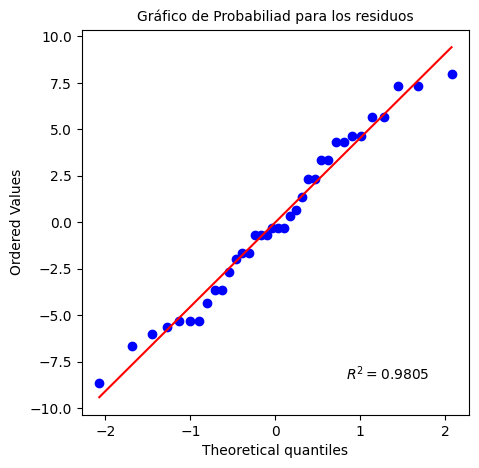

In [ ]:
# **b. Prueba gráfica con el gráfico de probabilidad Normal y el Histograma**
fig = plt.figure(figsize= (5, 5))
ax = fig.add_subplot(111)
normality_plot, stat = stats.probplot(modeloD2F.resid, plot= plt, rvalue= True)
ax.set_title("Gráfico de Probabiliad para los residuos", fontsize= 10)
ax.set

plt.show()

## **C. Histograma + curva normal teórica**

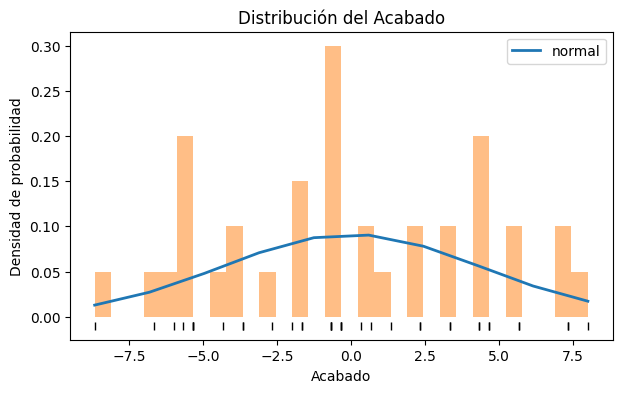

In [ ]:
## **c. Histograma + curva normal teórica**
# ==============================================================================

# Valores de la media (mu) y desviación típica (sigma) de los datos
tgp2 = modeloD2F.resid
mu, sigma = stats.norm.fit(tgp2)

# Valores teóricos de la normal en el rango observado
x_hat = np.linspace(min(tgp2), max(tgp2), num=10)
y_hat = stats.norm.pdf(x_hat, mu, sigma)

# Gráfico
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(x_hat, y_hat, linewidth=2, label='normal')
ax.hist(x=tgp2, density=True, bins=30,  alpha=0.5)
ax.plot(tgp2, np.full_like(tgp2, -0.01), '|k', markeredgewidth=1)
ax.set_title('Distribución del Acabado')
ax.set_xlabel('Acabado')
ax.set_ylabel('Densidad de probabilidad')
ax.legend();

## **d. Homocedasticidad de los residuos: Usando la prueba de Levene**

In [ ]:
# d. Homocedasticidad de los residuos: Usando la prueba de Levene
stats.levene(D2F['Acabado'][D2F['Profundidad'] == 0.15],
             D2F['Acabado'][D2F['Profundidad'] == 0.18],
             D2F['Acabado'][D2F['Profundidad'] == 0.21],
            D2F['Acabado'][D2F['Profundidad'] == 0.24])

LeveneResult(statistic=1.6933626601112695, pvalue=0.18808805130523845)

In [ ]:
# d. Homocedasticidad de los residuos: Usando la prueba de Levene
stats.levene(D2F['Acabado'][D2F['Velocidad'] == 0.20],
             D2F['Acabado'][D2F['Velocidad'] == 0.25],
             D2F['Acabado'][D2F['Velocidad'] == 0.30])

LeveneResult(statistic=5.767080745341613, pvalue=0.007112804860195111)

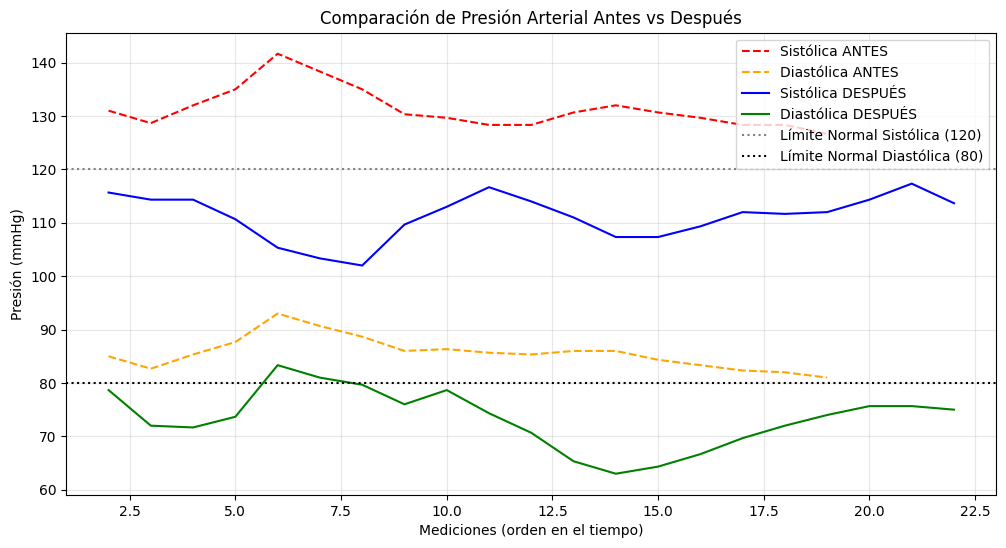

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Datos "ANTES"
# -----------------------------
sistolica_antes = [133, 128, 132, 126, 138, 141, 146, 128, 131, 132, 126, 127, 132, 133, 131, 128, 130, 127, 128, 125]
diastolica_antes = [87, 82, 86, 80, 90, 93, 96, 83, 87, 88, 84, 85, 87, 86, 85, 82, 83, 82, 81, 80]

# -----------------------------
# Datos "DESPUÉS"
# -----------------------------
sistolica_despues = [119, 113, 115, 115, 113, 104, 99, 107, 100, 122, 117, 111, 114, 108, 100, 114, 114, 108, 113, 115, 115, 122, 104]
diastolica_despues = [79, 79, 78, 59, 78, 84, 88, 71, 80, 77, 79, 67, 66, 63, 60, 70, 70, 69, 77, 76, 74, 77, 74]

# Crear DataFrames
df_antes = pd.DataFrame({"Sistólica": sistolica_antes, "Diastólica": diastolica_antes})
df_despues = pd.DataFrame({"Sistólica": sistolica_despues, "Diastólica": diastolica_despues})

# -----------------------------
# Gráfico comparativo
# -----------------------------
plt.figure(figsize=(12,6))

# Promedios
plt.plot(df_antes["Sistólica"].rolling(3).mean(), label="Sistólica ANTES", color="red", linestyle="--")
plt.plot(df_antes["Diastólica"].rolling(3).mean(), label="Diastólica ANTES", color="orange", linestyle="--")
plt.plot(df_despues["Sistólica"].rolling(3).mean(), label="Sistólica DESPUÉS", color="blue")
plt.plot(df_despues["Diastólica"].rolling(3).mean(), label="Diastólica DESPUÉS", color="green")

# Líneas de referencia clínicas
plt.axhline(120, color="gray", linestyle=":", label="Límite Normal Sistólica (120)")
plt.axhline(80, color="black", linestyle=":", label="Límite Normal Diastólica (80)")

# Personalización
plt.title("Comparación de Presión Arterial Antes vs Después")
plt.xlabel("Mediciones (orden en el tiempo)")
plt.ylabel("Presión (mmHg)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


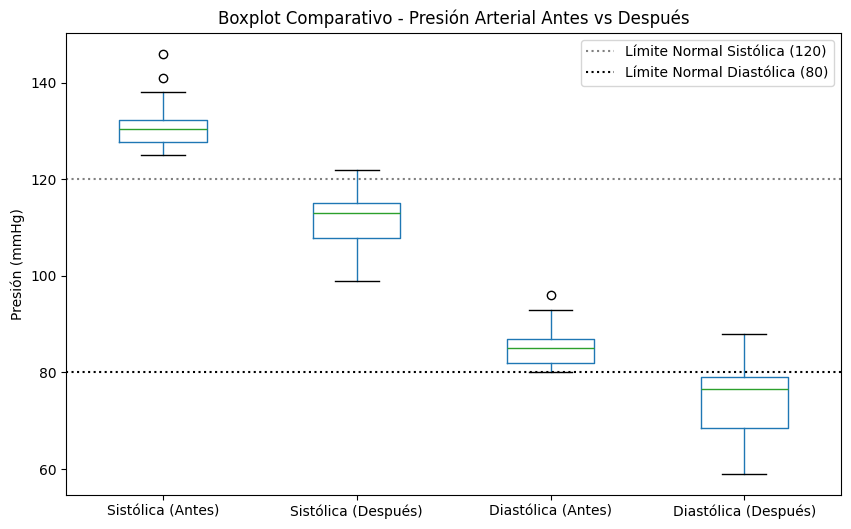

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Datos "ANTES"
# -----------------------------
sistolica_antes = [133, 128, 132, 126, 138, 141, 146, 128, 131, 132, 126, 127, 132, 133, 131, 128, 130, 127, 128, 125]
diastolica_antes = [87, 82, 86, 80, 90, 93, 96, 83, 87, 88, 84, 85, 87, 86, 85, 82, 83, 82, 81, 80]

# -----------------------------
# Datos "DESPUÉS"
# -----------------------------
sistolica_despues = [119, 113, 115, 115, 113, 104, 99, 107, 100, 122, 117, 111, 114, 108, 100, 114, 114, 108, 113, 115, 115, 122, 104]
diastolica_despues = [79, 79, 78, 59, 78, 84, 88, 71, 80, 77, 79, 67, 66, 63, 60, 70, 70, 69, 77, 76, 74, 77, 74]

# Crear DataFrame para el boxplot
df = pd.DataFrame({
    "Sistólica (Antes)": sistolica_antes,
    "Sistólica (Después)": sistolica_despues[:len(sistolica_antes)],  # igualar tamaño
    "Diastólica (Antes)": diastolica_antes,
    "Diastólica (Después)": diastolica_despues[:len(diastolica_antes)]
})

# -----------------------------
# Boxplot comparativo
# -----------------------------
plt.figure(figsize=(10,6))
df.boxplot(column=["Sistólica (Antes)", "Sistólica (Después)",
                   "Diastólica (Antes)", "Diastólica (Después)"],
           grid=False)

# Líneas de referencia clínicas
plt.axhline(120, color="gray", linestyle=":", label="Límite Normal Sistólica (120)")
plt.axhline(80, color="black", linestyle=":", label="Límite Normal Diastólica (80)")

plt.title("Boxplot Comparativo - Presión Arterial Antes vs Después")
plt.ylabel("Presión (mmHg)")
plt.legend()
plt.show()


He analizado tu informe de laboratorio 📄 y aquí te hago una evaluación general de tus resultados (recuerda que esto no reemplaza la valoración médica, pero te da una orientación):

---

## 🔹 Perfil iónico

* **Sodio sérico: 139 mmol/L** (Referencia: 136–145) ✅ Normal.
* **Cloro sérico: 100 mmol/L** (Referencia: 98–107) ✅ Normal.
* **Potasio sérico: 4.1 mmol/L** (Referencia: 3.5–5.1) ✅ Normal.

👉 Tus electrolitos están bien, no hay alteraciones.

---

## 🔹 Perfil lipídico

* **Colesterol total: 199 mg/dL** (Referencia: <200) ✅ Óptimo, en el límite alto de lo normal.

* **Colesterol HDL (el “bueno”): 34 mg/dL**

  * En hombres, lo ideal es **>55 mg/dL**.
  * Entre 35–55 se considera **riesgo moderado**.
  * <35 es **alto riesgo**.
    👉 Tu valor está en el **límite de alto riesgo cardiovascular**.

* **Triglicéridos: 349 mg/dL** (Referencia: 50–150) 🚨 Elevados.

  * Normal: <150
  * Límite: 150–199
  * Alto: 200–499
    👉 Tu valor está en rango **alto**.

---

## 🔹 Función renal

* **Creatinina sérica: 1.26 mg/dL** (Referencia: 0.67–1.17) 🔸 Ligeramente elevada.

  * Puede indicar cierta sobrecarga renal o deshidratación.
  * Recomendable correlacionar con **tasa de filtración glomerular (TFG)** y otros parámetros.

---

## ✅ Conclusión general

* Electrólitos: **normales**.
* Colesterol total: **en el límite superior**, pero aceptable.
* HDL: **bajo** → aumenta el riesgo cardiovascular.
* Triglicéridos: **altos**, requieren intervención (dieta, ejercicio, control médico).
* Creatinina: **ligeramente elevada**, conviene vigilar función renal.

---

📌 **Recomendaciones generales (no médicas, solo orientativas):**

1. Reducir consumo de azúcares, harinas refinadas y alcohol (para bajar triglicéridos).
2. Incrementar ejercicio aeróbico y dieta rica en frutas, verduras y pescado (para subir HDL).
3. Hidratación adecuada (para ayudar a riñón).
4. Llevar este resultado a tu médico para valoración completa y posible ajuste de tratamiento.

---

¿Quieres que te arme un **resumen visual en tabla con color (verde = normal, amarillo = límite, rojo = alterado)** para que lo tengas más claro y fácil de revisar?
